In [ ]:
!pip install xgboost optuna scikit-learn pandas numpy

In [ ]:
import pandas as pd

df = pd.read_csv('/content/synthetic_insurance_claims_with_fraud_3%_label.csv').drop(columns=['fraud_probability_score'])

print(df.columns, len(df), len(df.columns))
print(df['fraud_label'].sum() / len(df) * 100)
print(df['claim_number'].value_counts())

Index(['claim_days_differenc', 'claim_loss_date_dom',
       'claim_loss_datet_to_policy_ply_icp_dt_delta',
       'claim_loss_date_to_policy_str_date_delta', 'claim_loss_type_ab',
       'claim_loss_type_ad', 'claim_loss_type_al', 'claim_loss_type_eo',
       'claim_loss_type_es', 'claim_loss_type_ew', 'claim_loss_type_fi',
       'claim_loss_type_fl', 'claim_loss_type_gm', 'claim_loss_type_im',
       'claim_loss_type_lb', 'claim_loss_type_mc', 'claim_loss_type_md',
       'claim_loss_type_rl', 'claim_loss_type_st', 'claim_loss_type_th',
       'claim_number', 'claim_report_date_to_policy_ori_qte_dt_delta',
       'sum_insured', 'reinstatement_value', 'credit_risk_score',
       'total_active_associate_cai', 'barriers_wide_score',
       'children_population', 'insurance_indicator', 'oc_code', 'policy_api',
       'policy_claim_free_year', 'policy_cld_cst1_aggregate',
       'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 'prop_prv_isn_cne',
       'risk_band1', 'risk_band2', 'risk_ban

In [ ]:
import pandas as pd
import numpy as np

# Assuming 'df' is your loaded DataFrame
# 1. Create a categorical flag for sum_insured
df['sum_insured_cat'] = np.where(df['sum_insured'] > 0, 'Positive (>0)', 'Zero (=0)')

# 2. Create the cross-tabulation (Table)
count_table = pd.crosstab(df['sum_insured_cat'], df['fraud_label'])

# 3. Display the table
print(count_table)

fraud_label          0     1
sum_insured_cat             
Positive (>0)    91084  2821
Zero (=0)         1063    32


#### Numerical data distribution = (Gaussian + random noise addition)

14


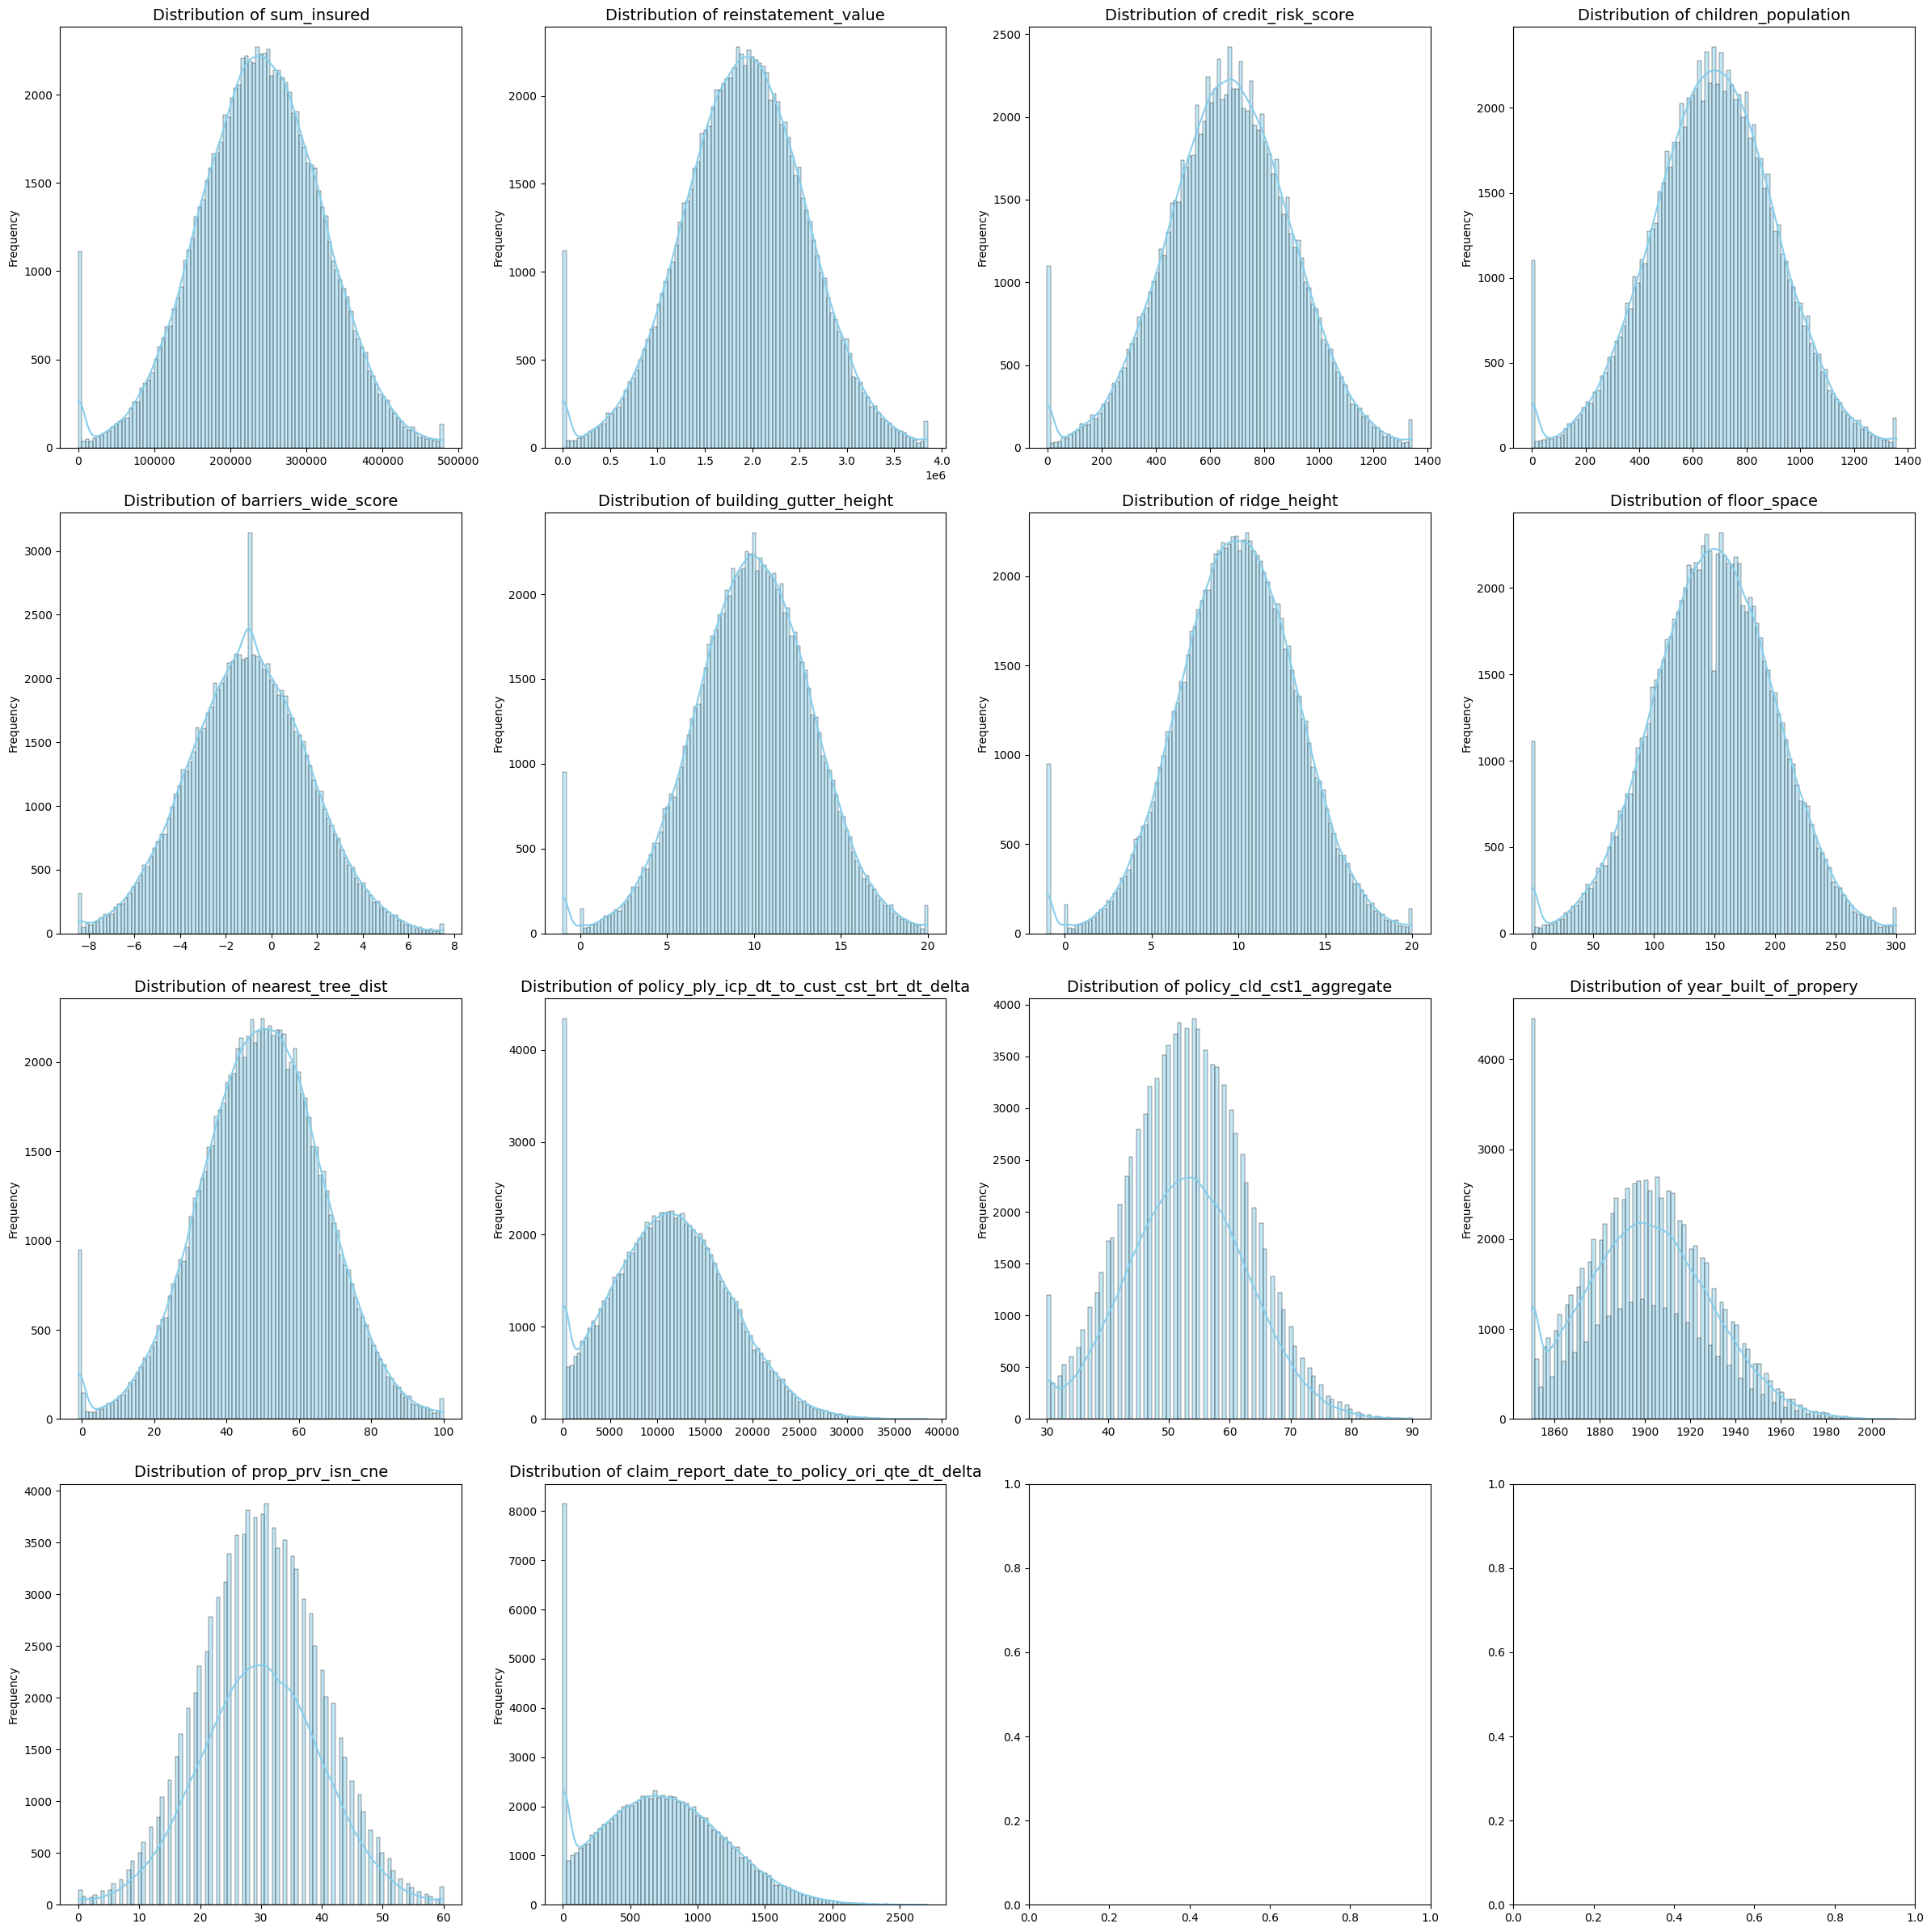

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your column list
continuous = [
    'sum_insured', 'reinstatement_value', 'credit_risk_score',
    'children_population', 'barriers_wide_score', 'building_gutter_height',
    'ridge_height', 'floor_space', 'nearest_tree_dist', 'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 'policy_cld_cst1_aggregate',
    'year_built_of_propery', 'prop_prv_isn_cne', 'claim_report_date_to_policy_ori_qte_dt_delta'
]

print(len(continuous))
fig, axes = plt.subplots(4, 4, figsize=(24, 24))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop through the columns and create the plots
for i, col in enumerate(continuous):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

#### Categorical distribution

31


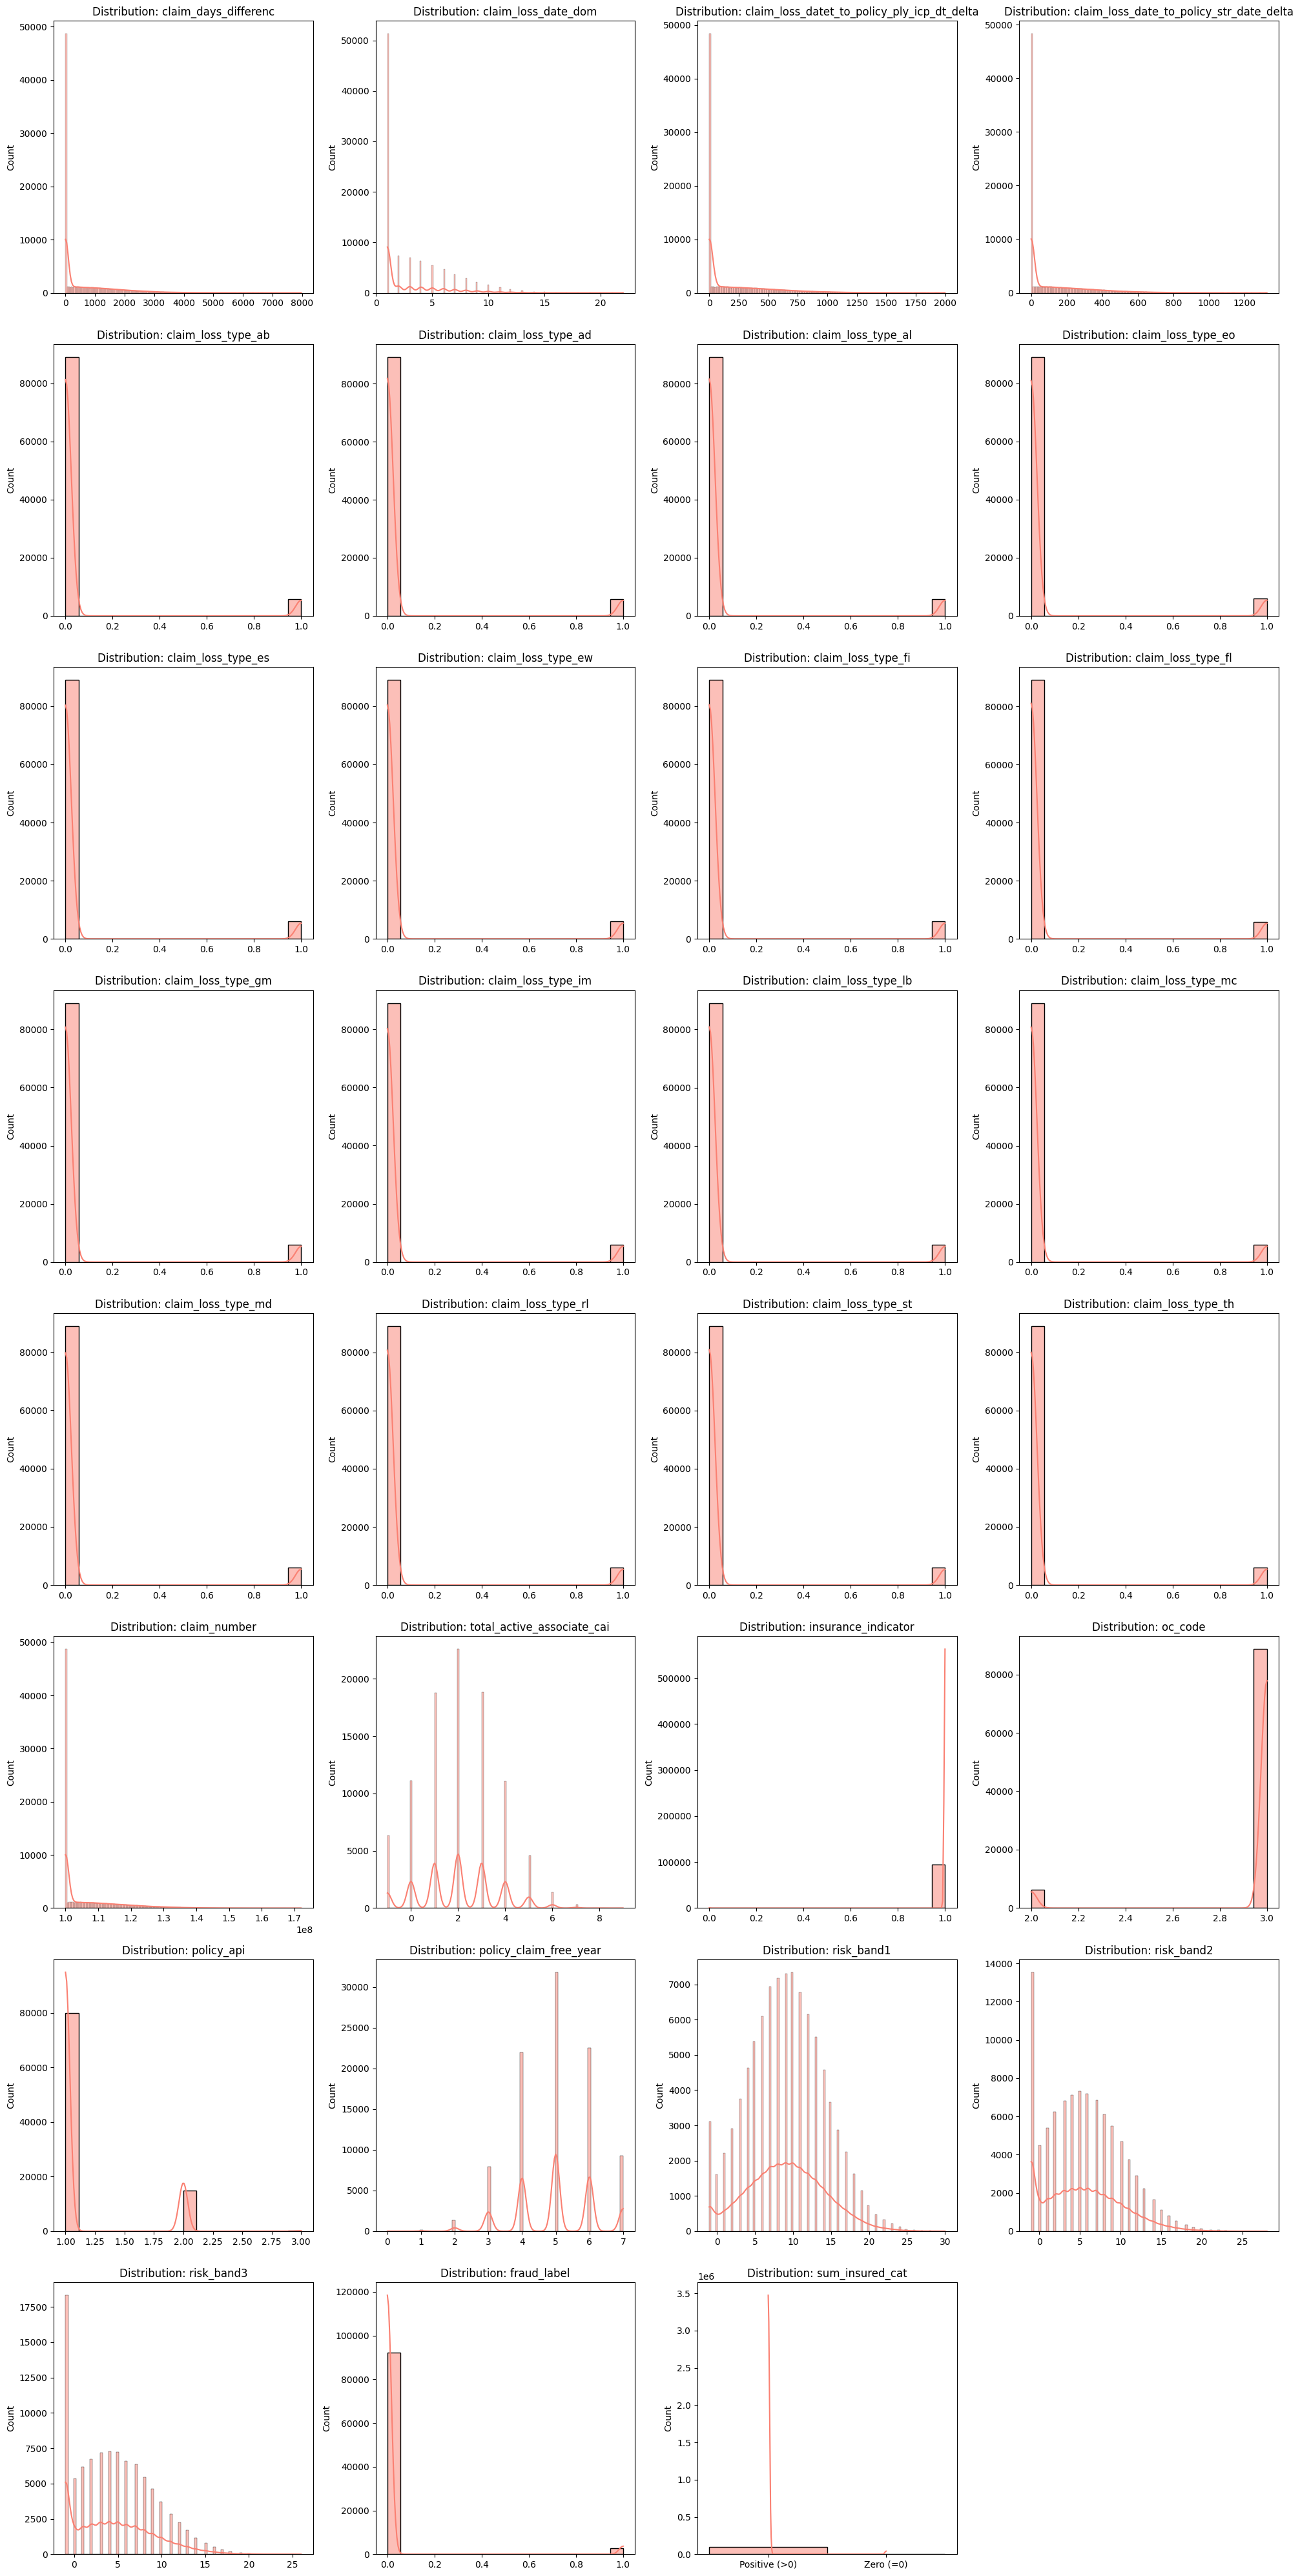

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Define the original list to exclude
continuous = [
    'sum_insured', 'reinstatement_value', 'credit_risk_score',
    'children_population', 'barriers_wide_score', 'building_gutter_height',
    'ridge_height', 'floor_space', 'nearest_tree_dist', 'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 'policy_cld_cst1_aggregate',
    'year_built_of_propery', 'prop_prv_isn_cne', 'claim_report_date_to_policy_ori_qte_dt_delta'
]

# 2. Get the list of remaining columns
# We use df_result.columns to get the current order and filter out the ones already plotted
remaining_cols = [col for col in df.columns if col not in continuous]
print(len(remaining_cols))
# 3. Calculate grid dimensions (e.g., 4 columns wide)
n_cols = 4
n_rows = math.ceil(len(remaining_cols) / n_cols)

# 4. Create the plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(remaining_cols):
    # Plot histogram with KDE for each remaining column
    sns.histplot(df[col], kde=True, ax=axes[i], color='salmon')
    axes[i].set_title(f'Distribution: {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Remove any empty subplots if the grid is larger than the number of columns
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Tweedie and Dual model approach

✅ Config loaded.
Loaded 95,000 rows | fraud=3.00%
Labeled: 65,000 | Unlabeled: 30,000
c1_train=45,000 | c1_val=10,000 | c1_test=10,000
c2_test=10,000 | unlabeled pool=20,000
✅ Data splits ready.
✅ Helper functions defined.
[Params] Loaded from 'best_params.json'
  Threshold    : 0.1085
  N_ESTIMATORS : 507
  max_depth                 = 5
  min_child_weight          = 4
  gamma                     = 0.45606998421703593
  learning_rate             = 0.12448918446337819
  subsample                 = 0.5998368910791798
  colsample_bytree          = 0.708540663048167
  colsample_bylevel         = 0.7554487413172255
  reg_alpha                 = 2.4298880728901692e-08
  reg_lambda                = 0.0019275890163896973
  objective                 = binary:logistic
  tree_method               = hist
  seed                      = 42

[Baseline] Training …
[Baseline] AUC=0.9533 | Business cost=232,950
✅ Baseline model saved → baseline_model.json
✅ Dual-Model, Tweedie & ECR helpers defined.

═══

AL [dual_model]:   0%|          | 0/10 [00:00<?, ?it/s]

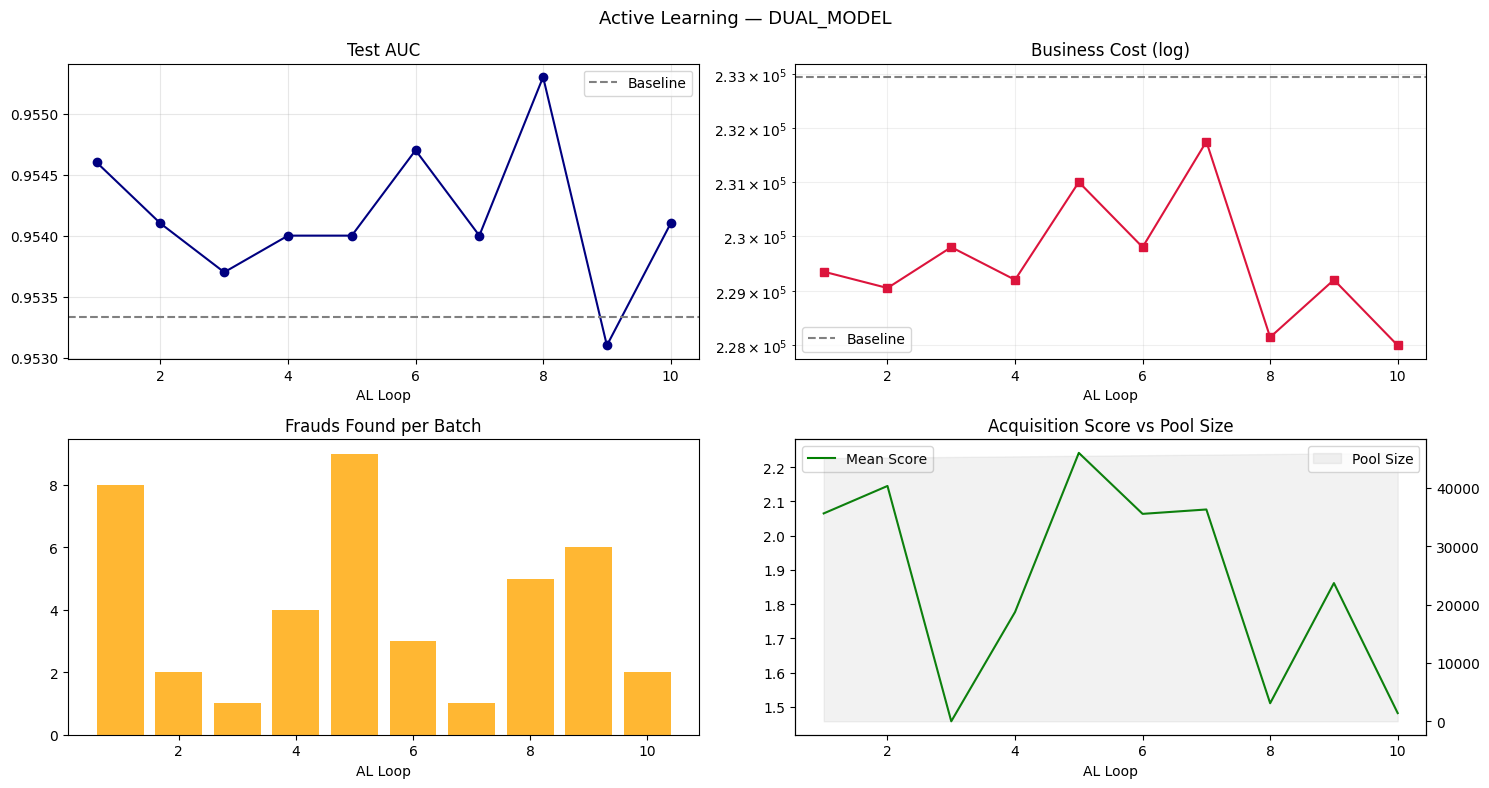

Plot saved → al_progress_dual_model.png

✅ dual_model AL complete.
 loop  train_pool_size  unlabeled_remaining  fraud_in_query  mean_score  test_auc  test_business_cost
    1            45100                18000               8      2.0646    0.9546            229350.0
    2            45200                16000               2      2.1447    0.9541            229050.0
    3            45300                14000               1      1.4581    0.9537            229800.0
    4            45400                12000               4      1.7769    0.9540            229200.0
    5            45500                10000               9      2.2412    0.9540            231000.0
    6            45600                 8000               3      2.0633    0.9547            229800.0
    7            45700                 6000               1      2.0761    0.9540            231750.0
    8            45800                 4000               5      1.5108    0.9553            228150.0
    9          

AL [tweedie]:   0%|          | 0/10 [00:00<?, ?it/s]

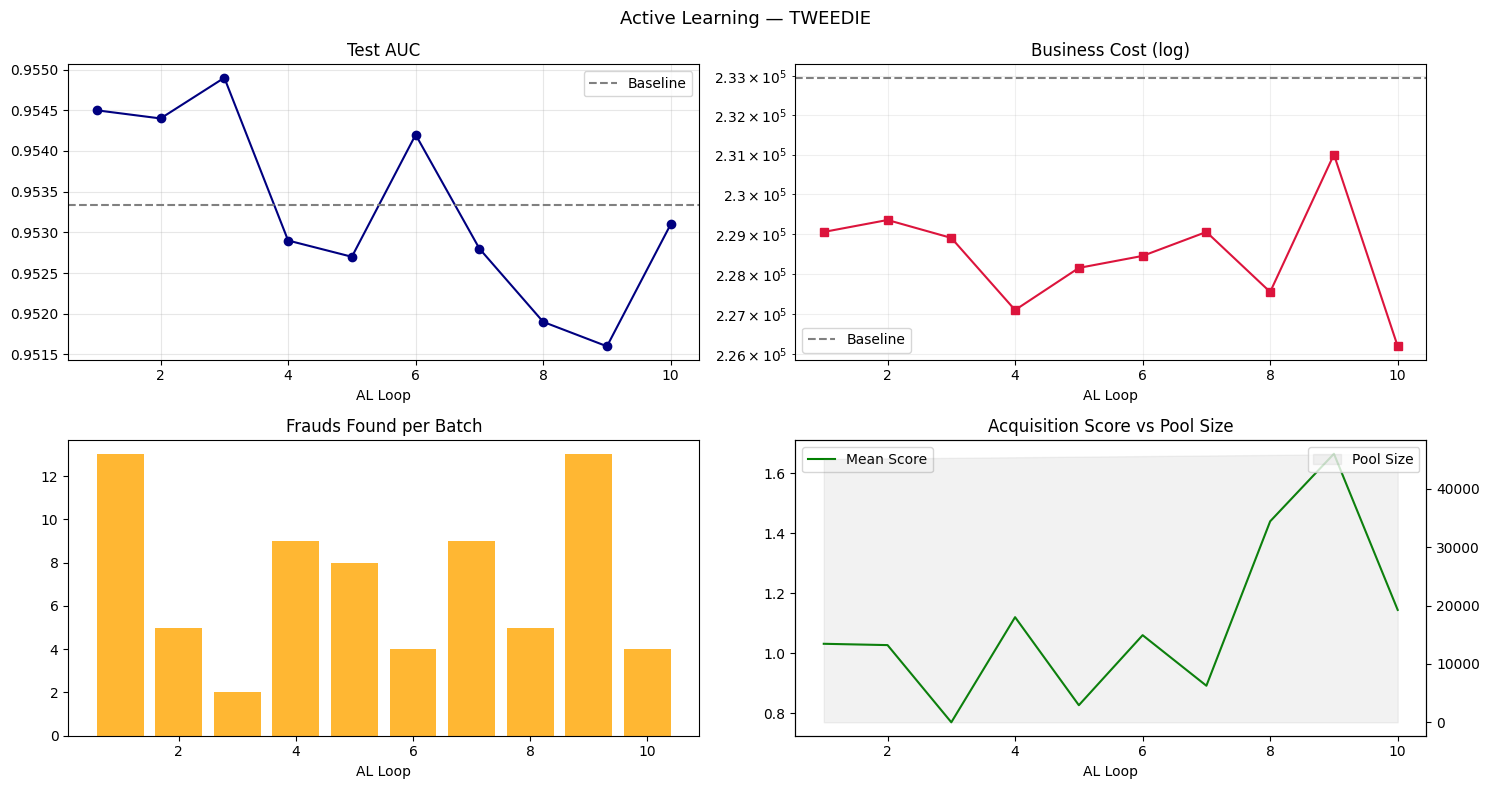

Plot saved → al_progress_tweedie.png

✅ tweedie AL complete.
 loop  train_pool_size  unlabeled_remaining  fraud_in_query  mean_score  test_auc  test_business_cost
    1            45100                18000              13      1.0317    0.9545            229050.0
    2            45200                16000               5      1.0273    0.9544            229350.0
    3            45300                14000               2      0.7700    0.9549            228900.0
    4            45400                12000               9      1.1204    0.9529            227100.0
    5            45500                10000               8      0.8270    0.9527            228150.0
    6            45600                 8000               4      1.0604    0.9542            228450.0
    7            45700                 6000               9      0.8919    0.9528            229050.0
    8            45800                 4000               5      1.4399    0.9519            227550.0
    9            4590

AL [ecr]:   0%|          | 0/10 [00:00<?, ?it/s]

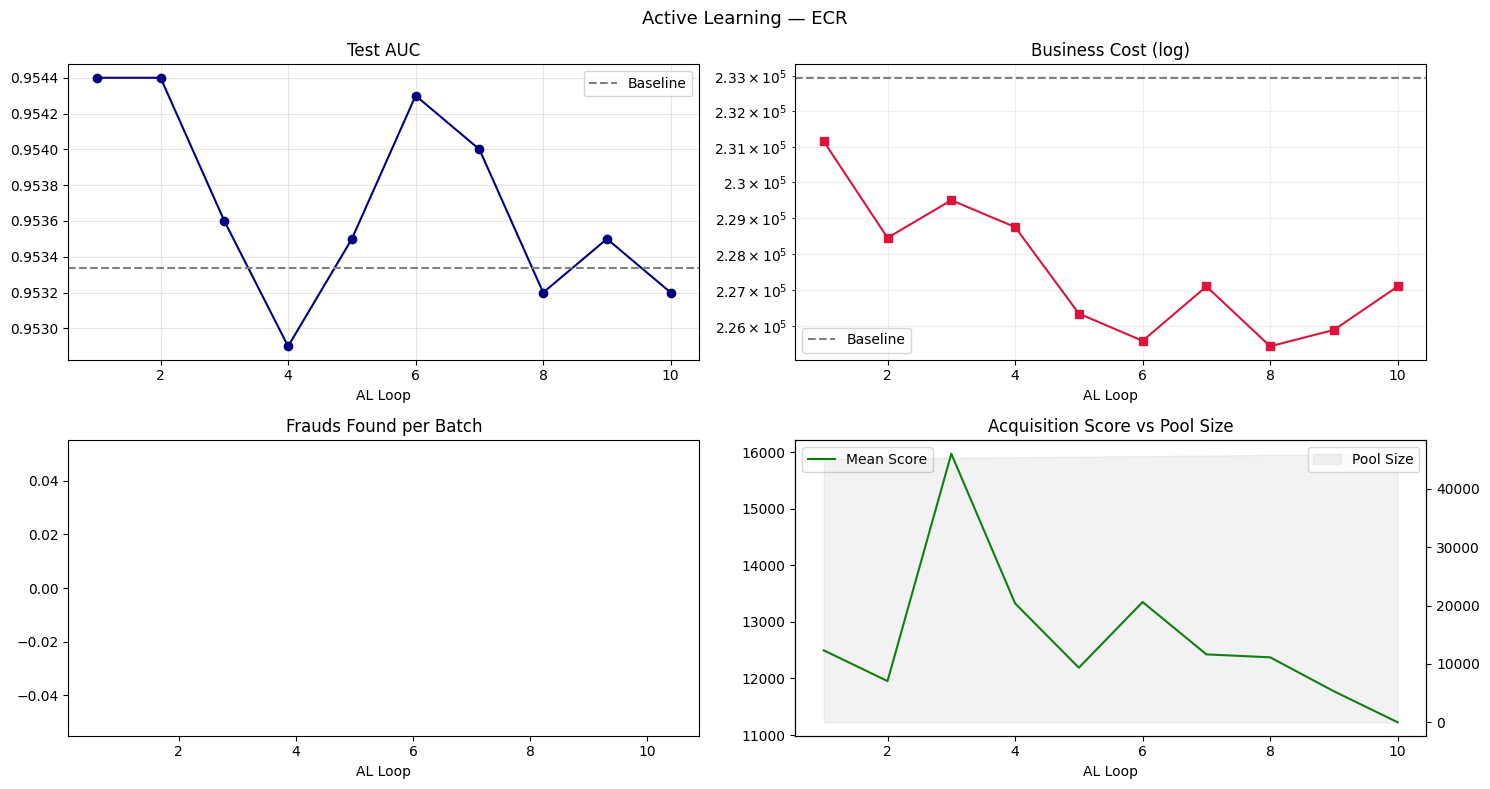

Plot saved → al_progress_ecr.png

✅ ecr AL complete.
 loop  train_pool_size  unlabeled_remaining  fraud_in_query  mean_score  test_auc  test_business_cost
    1            45100                18000               0  12497.1283    0.9544            231150.0
    2            45200                16000               0  11954.1163    0.9544            228450.0
    3            45300                14000               0  15974.5543    0.9536            229500.0
    4            45400                12000               0  13328.3489    0.9529            228750.0
    5            45500                10000               0  12190.3850    0.9535            226350.0
    6            45600                 8000               0  13352.0141    0.9543            225600.0
    7            45700                 6000               0  12426.2112    0.9540            227100.0
    8            45800                 4000               0  12373.9245    0.9532            225450.0
    9            45900       

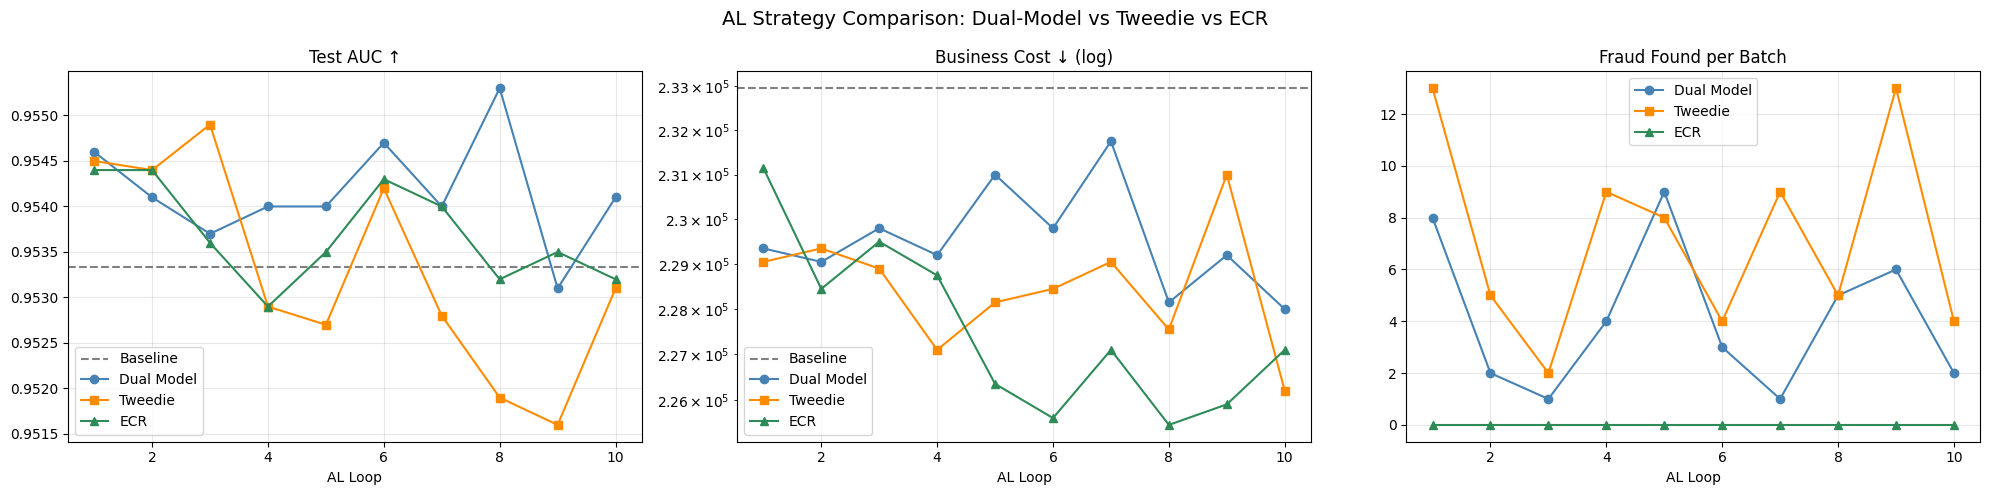

Plot saved → al_strategy_comparison.png

────────────────────────────────────────────────────────────────────────────────
  FINAL SUMMARY — c2_test set
────────────────────────────────────────────────────────────────────────────────
                    auc  biz_cost  precision  recall      f1
model                                                       
Baseline         0.9533  232950.0     0.1815     1.0  0.3072
AL — Dual Model  0.9541  228000.0     0.1852     1.0  0.3125
AL — Tweedie     0.9531  226200.0     0.1866     1.0  0.3145
AL — ECR         0.9532  227100.0     0.1859     1.0  0.3135
────────────────────────────────────────────────────────────────────────────────

  AL — Dual Model                      ΔAUC=+0.0008  ΔCost=-4,950 ✅

  AL — Tweedie                         ΔAUC=-0.0002  ΔCost=-6,750 ✅

  AL — ECR                             ΔAUC=-0.0001  ΔCost=-5,850 ✅


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  COMPLETE SELF-CONTAINED SCRIPT
#  Insurance Fraud Detection — Active Learning with Dual Model, Tweedie & ECR
#
#  PREREQUISITES:
#   1. The synthetic CSV from the data-generation notebook must exist.
#      Set DATA_CSV below to its path.
#   2. best_params.json (from your earlier Optuna run) must exist.
#      Set BEST_PARAMS_JSON below to its path.
#   3. pip install xgboost lightgbm scikit-learn pandas numpy tqdm
#
#  WHAT THIS DOES (end-to-end):
#   Section 1  → Imports & Config
#   Section 2  → Load data, splits (labeled/unlabeled, c1, c2)
#   Section 3  → All helper functions (cost, weights, build_model)
#   Section 4  → Load best_params.json → xgb_params, N_ESTIMATORS, THRESHOLD
#   Section 5  → Baseline model (trained on c1_train, evaluated on c2_test)
#   Section 6  → Dual-Model AL  (Frequency × Severity as acquisition fn)
#               Tweedie AL      (Compound Poisson-Gamma as acquisition fn)
#               ECR AL          (Expected Cost Reduction as acquisition fn)
#   Section 7  → Generic AL loop
#   Section 8  → Run ALL strategies, and Final comparison plot & table
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 1 — IMPORTS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────

# Uncomment if running in Colab:
# !pip install xgboost lightgbm scikit-learn pandas numpy tqdm --quiet

import os, json, warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm          # swap for tqdm.tqdm if not in Jupyter
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings("ignore")

# ── User config ───────────────────────────────────────────────────────────────
DATA_CSV        = "synthetic_insurance_claims_with_fraud_3%_label.csv"
TARGET_COL      = "fraud_label"
SUM_INSURED_COL = "sum_insured"

COST_TP         = 100
COST_FP         = 150
COST_TN         = 0

BEST_PARAMS_JSON = "best_params.json"

# Active Learning
N_AL_LOOPS         = 10
N_QUERY_PER_LOOP   = 100
N_SUBSAMPLE        = 2000
EARLY_STOPPING     = 50

# Hybrid AL
N_CANDIDATES_PER_STRAT = 200
N_MAX_INTERSECT        = 100

TWEEDIE_POWER   = 1.1    # p ∈ (1,2); 1.5 is actuarial default

# Output paths
DUAL_MODEL_CSV        = "al_queried_labels_dual_model.csv"
DUAL_MODEL_PATH       = "al_dual_model_booster.json"
TWEEDIE_CSV           = "al_queried_labels_tweedie.csv"
TWEEDIE_PATH          = "al_tweedie_booster.json"
ECR_CSV               = "al_queried_labels_ecr.csv"          # ← NEW
ECR_MODEL_PATH        = "al_ecr_booster.json"                # ← NEW
BASELINE_MODEL_PATH   = "baseline_model.json"
FINAL_NSL_MODEL_PATH  = "nonsequential_final_model.json"

print("✅ Config loaded.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 2 — LOAD DATA & SPLITS
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_CSV).drop(columns=["fraud_probability_score"], errors="ignore")

# Fix NaN labels
if df[TARGET_COL].isnull().any():
    df[TARGET_COL] = df[TARGET_COL].fillna(0).astype(int)
else:
    df[TARGET_COL] = df[TARGET_COL].astype(int)

print(f"Loaded {len(df):,} rows | fraud={df[TARGET_COL].mean()*100:.2f}%")

# ── labeled (65k) / unlabeled (30k) ──────────────────────────────────────────
df_labeled, df_unlabeled = train_test_split(
    df, test_size=30000, random_state=42, stratify=df[TARGET_COL]
)
print(f"Labeled: {len(df_labeled):,} | Unlabeled: {len(df_unlabeled):,}")

# ── Case 1 splits (all from labeled) ─────────────────────────────────────────
c1_train_data, c1_val_data = train_test_split(
    df_labeled, test_size=20000, random_state=42, stratify=df_labeled[TARGET_COL]
)
c1_test_data, c1_val_data = train_test_split(
    c1_val_data, test_size=10000, random_state=42, stratify=c1_val_data[TARGET_COL]
)

# ── Case 2 splits (test from unlabeled pool) ──────────────────────────────────
c2_train_data, c2_val_data = train_test_split(
    df_labeled, test_size=20000, random_state=42, stratify=df_labeled[TARGET_COL]
)
c2_test_data, df_remaining_unlabeled = train_test_split(
    df_unlabeled, train_size=10000,
    stratify=df_unlabeled[TARGET_COL], random_state=42
)

print(f"c1_train={len(c1_train_data):,} | c1_val={len(c1_val_data):,} | c1_test={len(c1_test_data):,}")
print(f"c2_test={len(c2_test_data):,} | unlabeled pool={len(df_remaining_unlabeled):,}")

# ── Pre-shuffle unlabeled pool (non-overlapping chunks across AL loops) ───────
rng            = np.random.default_rng(seed=42)
shuffled_order = rng.permutation(len(df_remaining_unlabeled))
df_remaining_unlabeled_pool = (
    df_remaining_unlabeled.copy().iloc[shuffled_order].reset_index(drop=True)
)

# ── Oracle (unlabeled rows kept with their true labels for simulated labelling)
df_unlabeled_oracle    = df_unlabeled.copy()
unlabeled_oracle_join_cols = [
    c for c in df_remaining_unlabeled_pool.columns if c != TARGET_COL
]

assert N_SUBSAMPLE * N_AL_LOOPS <= len(df_remaining_unlabeled_pool), \
    f"Pool too small: need {N_SUBSAMPLE*N_AL_LOOPS:,} rows but have {len(df_remaining_unlabeled_pool):,}"

print("✅ Data splits ready.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 3 — HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def compute_business_cost(y_true, y_pred_proba, sum_insured_vals,
                           threshold=0.5, cost_tp=COST_TP, cost_fp=COST_FP):
    """FN = 0.9 × sum_insured (missed fraud payout). Lower is better."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    cost   = np.zeros(len(y_true), dtype=np.float64)
    cost[(y_pred == 1) & (y_true == 1)] = cost_tp
    cost[(y_pred == 1) & (y_true == 0)] = cost_fp
    fn_mask = (y_pred == 0) & (y_true == 1)
    cost[fn_mask] = 0.9 * np.maximum(sum_insured_vals[fn_mask], 0)
    return float(np.sum(cost))


def make_sample_weights(y_train_fold, si_train_fold):
    """Fraud rows → weight = 0.9 × sum_insured; non-fraud → COST_FP."""
    weights = np.where(
        y_train_fold == 1,
        0.9 * np.maximum(si_train_fold, 0),
        COST_FP
    ).astype(np.float64)
    weights = np.maximum(weights, 1e-6)
    return weights / weights.mean()


def business_cost_custom_metric(y_proba, dtrain, si_vals, threshold):
    y_true = dtrain.get_label()
    cost   = compute_business_cost(y_true, y_proba, si_vals, threshold=threshold)
    return "business_cost", cost / max(len(y_true), 1)


def build_and_train_model(params, n_estimators, threshold,
                            X_train, y_train, si_train):
    """Train XGBoost booster with business-cost early stopping."""
    sw     = make_sample_weights(y_train, si_train)
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=sw)
    dval   = xgb.DMatrix(X_train, label=y_train)   # use train as ES proxy

    def _cost_eval(y_proba, dtrain_inner, _si=si_train, _th=threshold):
        return business_cost_custom_metric(y_proba, dtrain_inner, _si, _th)

    xgb_train_params = {
        "objective"  : "binary:logistic",
        "tree_method": "hist",
        "seed"       : 42,
        "verbosity"  : 0,
        **params,
    }
    booster = xgb.train(
        xgb_train_params,
        dtrain,
        num_boost_round       = n_estimators,
        evals                 = [(dval, "train")],
        custom_metric         = _cost_eval,
        early_stopping_rounds = EARLY_STOPPING,
        maximize              = False,
        verbose_eval          = False,
    )
    return booster


def load_params_from_json(json_path):
    with open(json_path) as f:
        raw = json.load(f)
    params       = {k: v for k, v in raw.items() if not k.startswith("_")}
    threshold    = params.pop("threshold", 0.5)
    n_estimators = params.pop("n_estimators", 300)
    return params, n_estimators, threshold


def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba      = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred       = (y_proba >= threshold).astype(int)
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)
    print(f"\n{'═'*62}\n  {label}\n{'═'*62}")
    print(f"  Threshold : {threshold:.4f} | AUC: {auc:.4f}")
    print(f"  Biz cost  : {biz_cost:>12,.2f}  (per row: {cost_per_row:,.4f})")
    print(f"  TP/FP/TN/FN: {tp}/{fp}/{tn}/{fn}")
    print(f"  Precision : {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"{'═'*62}")
    return dict(model=label, auc=round(auc,4), biz_cost=round(biz_cost,2),
                cost_per_row=round(cost_per_row,4), tp=tp, fp=fp, tn=tn, fn=fn,
                precision=round(precision,4), recall=round(recall,4), f1=round(f1,4))


print("✅ Helper functions defined.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 4 — LOAD HYPERPARAMETERS FROM best_params.json
#  Replaces Optuna tuning. Reads xgb_params, N_ESTIMATORS, THRESHOLD
#  directly from your existing JSON file.
# ─────────────────────────────────────────────────────────────────────────────

xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

# load_params_from_json strips "threshold", "n_estimators", and "_meta" keys,
# then returns the remainder as xgb_params. We add the fixed training keys back.
xgb_params["objective"]   = "binary:logistic"
xgb_params["tree_method"] = "hist"
xgb_params["seed"]        = 42

print(f"[Params] Loaded from '{BEST_PARAMS_JSON}'")
print(f"  Threshold    : {THRESHOLD:.4f}")
print(f"  N_ESTIMATORS : {N_ESTIMATORS}")
for k, v in xgb_params.items():
    print(f"  {k:<25} = {v}")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 5 — BASELINE MODEL
#  Trained on c1_train_data, evaluated on c2_test_data (unlabeled-origin test).
# ─────────────────────────────────────────────────────────────────────────────

X_pool_train  = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_train  = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool_train = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

print("\n[Baseline] Training …")
baseline_model = build_and_train_model(
    xgb_params, N_ESTIMATORS, THRESHOLD,
    X_pool_train, y_pool_train, si_pool_train
)
baseline_model.save_model(BASELINE_MODEL_PATH)

X_c2_test  = c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_c2_test  = c2_test_data[TARGET_COL].values.astype(np.int32)
si_c2_test = c2_test_data[SUM_INSURED_COL].values.astype(np.float64)

baseline_proba = baseline_model.predict(
    xgb.DMatrix(X_c2_test),
    iteration_range=(0, baseline_model.best_iteration + 1)
)
baseline_cost = compute_business_cost(y_c2_test, baseline_proba, si_c2_test, THRESHOLD)
baseline_auc  = roc_auc_score(y_c2_test, baseline_proba)

print(f"[Baseline] AUC={baseline_auc:.4f} | Business cost={baseline_cost:,.0f}")
print(f"✅ Baseline model saved → {BASELINE_MODEL_PATH}")

FEATURE_COLS = [c for c in df_labeled.columns
                if c not in [TARGET_COL, SUM_INSURED_COL]]


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 6 — DUAL-MODEL, TWEEDIE & ECR HELPERS
#  Implements slides pp. 9-13 as AL acquisition functions.
# ─────────────────────────────────────────────────────────────────────────────

# ── Dual Model ────────────────────────────────────────────────────────────────
def train_severity_model(X_train_df, y_arr, si_arr):
    """
    Gamma regression on sum_insured | fraud=1.
    Slides p.9: Severity model — GLM/GBM on positive amounts (Gamma conditioned
    on at least one claim).
    Returns lgb.LGBMRegressor or None if too few fraud rows.
    """
    mask   = (y_arr == 1) & (si_arr > 0.0)
    if mask.sum() < 10:
        return None
    X_sev  = X_train_df[mask]
    y_sev  = si_arr[mask]
    model  = lgb.LGBMRegressor(
        objective="gamma", learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        n_estimators=300, verbosity=-1, random_state=42,
    )
    model.fit(X_sev, y_sev)
    return model


def dual_model_query(X_unlabeled_df, si_vals, freq_proba, sev_model, n_query):
    """
    Acquisition function: uncertainty × log1p(E[freq] × E[severity]).
    Slides p.9: E[loss] = E[frequency] × E[severity].
    Falls back to raw sum_insured when sev_model is None.
    Returns (query_local_idx, scores).
    """
    e_sev       = sev_model.predict(X_unlabeled_df)
    e_sev       = np.maximum(e_sev, 0.0)
    e_loss      = freq_proba * e_sev
    uncertainty = 1.0 - np.abs(2.0 * freq_proba - 1.0)
    scores      = uncertainty * np.log1p(e_loss)
    return np.argsort(-scores)[:n_query], scores


# ── Tweedie Model ─────────────────────────────────────────────────────────────
def make_tweedie_target(y_arr, si_arr):
    """payout = fraud_label × sum_insured (zero-inflated, right-skewed)."""
    return y_arr.astype(np.float64) * np.maximum(si_arr, 0.0)


def train_tweedie_model(X_train_df, y_arr, si_arr):
    """
    Single compound Poisson-Gamma (Tweedie, p=1.5) model on payout.
    Slides pp.12-13: E[Y]=μ, Var(Y)=φμ^p, Y = Σ Z_i, N~Poisson, Z_i~Gamma.
    Returns lgb.LGBMRegressor or None if insufficient non-zero rows.
    """
    payout = make_tweedie_target(y_arr, si_arr)
    if (payout > 0).sum() < 5:
        return None
    model = lgb.LGBMRegressor(
        objective="tweedie", tweedie_variance_power=TWEEDIE_POWER,
        learning_rate=0.05, num_leaves=31, min_child_samples=5,
        n_estimators=300, verbosity=-1, random_state=42,
    )
    model.fit(X_train_df, payout)
    return model


def tweedie_query(X_unlabeled_df, freq_proba, tw_model, n_query):
    """
    Acquisition: uncertainty × log1p(Tweedie E[payout]).
    Slides p.12: single model handles zeros + continuous positives.
    Returns (query_local_idx, scores).
    """
    tw_pred     = np.maximum(tw_model.predict(X_unlabeled_df), 0.0)
    uncertainty = 1.0 - np.abs(2.0 * freq_proba - 1.0)
    scores      = uncertainty * np.log1p(tw_pred)
    return np.argsort(-scores)[:n_query], scores


# ── Expected Cost Reduction ───────────────────────────────────────────────────
def ecr_query(freq_proba, si_vals, threshold, n_query):
    """
    Acquisition function: Expected Cost Reduction (ECR).

    For each unlabeled row the model is currently carrying one of two risks:
      • If model predicts negative (proba < threshold):
            risk_if_0 = P(fraud) × 0.9 × sum_insured   ← cost of a missed fraud (FN)
      • If model predicts positive (proba ≥ threshold):
            risk_if_1 = P(not fraud) × COST_FP          ← cost of a false alarm (FP)

    We query the rows where the model's *current financial regret* is highest,
    i.e. the cases where labelling and retraining would most reduce expected cost.

    Returns (query_local_idx, scores).
    """
    risk_if_0 = freq_proba * (si_vals * 0.9)          # FN risk: missed fraud payout
    risk_if_1 = (1.0 - freq_proba) * COST_FP          # FP risk: false alarm cost
    scores    = np.where(freq_proba < threshold, risk_if_0, risk_if_1)
    return np.argsort(-scores)[:n_query], scores


print("✅ Dual-Model, Tweedie & ECR helpers defined.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 7 — GENERIC AL LOOP
#  Runs N_AL_LOOPS for a given query strategy.
#  strategy_name: "dual_model" | "tweedie" | "ecr"
# ─────────────────────────────────────────────────────────────────────────────

def run_al_loop(strategy_name, output_csv):
    assert strategy_name in ("dual_model", "tweedie", "ecr")

    if os.path.exists(output_csv):
        os.remove(output_csv)

    # Reset to baseline state
    current_model = baseline_model
    X_cur         = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
    y_cur         = c1_train_data[TARGET_COL].values.astype(np.int32)
    si_cur        = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

    al_log = []
    print(f"\n{'═'*65}")
    print(f"  Strategy: {strategy_name.upper()}")
    print(f"  {N_AL_LOOPS} loops × {N_QUERY_PER_LOOP} queries")
    print(f"{'═'*65}\n")

    for al_loop in tqdm(range(N_AL_LOOPS), desc=f"AL [{strategy_name}]"):
        s, e      = al_loop * N_SUBSAMPLE, (al_loop + 1) * N_SUBSAMPLE
        df_chunk  = df_remaining_unlabeled_pool.drop(columns=[TARGET_COL]).iloc[s:e]
        X_unlab   = df_chunk.drop(columns=[SUM_INSURED_COL])
        si_chunk  = df_chunk[SUM_INSURED_COL].values.astype(np.float64)

        # Step 1 — Fraud probabilities from XGBoost classifier
        freq_proba = current_model.predict(
            xgb.DMatrix(X_unlab),
            iteration_range=(0, current_model.best_iteration + 1)
        )

        # Step 2 — Train auxiliary model (if needed) & pick query indices
        if strategy_name == "dual_model":
            sev_model             = train_severity_model(X_cur, y_cur, si_cur)
            query_idx, scores     = dual_model_query(X_unlab, si_chunk,
                                                     freq_proba, sev_model,
                                                     N_QUERY_PER_LOOP)
        elif strategy_name == "tweedie":
            tw_model              = train_tweedie_model(X_cur, y_cur, si_cur)
            query_idx, scores     = tweedie_query(X_unlab, freq_proba,
                                                  tw_model, N_QUERY_PER_LOOP)
        else:  # ecr
            query_idx, scores     = ecr_query(freq_proba, si_chunk,
                                              THRESHOLD, N_QUERY_PER_LOOP)

        # Step 3 — Oracle lookup (simulated human labelling)
        query_df                   = df_chunk.iloc[query_idx].copy()
        query_df["al_pred_proba"]  = freq_proba[query_idx]
        query_df["al_uncertainty"] = scores[query_idx]
        merge_cols                 = [c for c in unlabeled_oracle_join_cols
                                      if c in query_df.columns]
        newly_labeled = pd.merge(
            query_df,
            df_unlabeled_oracle[unlabeled_oracle_join_cols + [TARGET_COL]],
            on=merge_cols, how="left"
        )
        assert newly_labeled[TARGET_COL].notna().all(), \
            f"Loop {al_loop+1}: oracle lookup failed."

        # Step 4 — Save to CSV
        save_df = newly_labeled[df_labeled.columns.tolist()
                                + ["al_pred_proba", "al_uncertainty"]].copy()
        save_df.to_csv(output_csv, mode="a",
                       header=not os.path.exists(output_csv), index=False)

        # Step 5 — Expand labeled pool
        X_new  = newly_labeled[FEATURE_COLS].values
        y_new  = newly_labeled[TARGET_COL].values.astype(np.int32)
        si_new = newly_labeled[SUM_INSURED_COL].values.astype(np.float64)
        X_cur  = pd.concat([X_cur, pd.DataFrame(X_new, columns=FEATURE_COLS)],
                            ignore_index=True)
        y_cur  = np.concatenate([y_cur,  y_new])
        si_cur = np.concatenate([si_cur, si_new])

        # Step 6 — Retrain XGBoost fraud classifier
        current_model = build_and_train_model(
            xgb_params, N_ESTIMATORS, THRESHOLD, X_cur, y_cur, si_cur
        )

        # Step 7 — Evaluate on c2_test
        test_proba = current_model.predict(
            xgb.DMatrix(X_c2_test),
            iteration_range=(0, current_model.best_iteration + 1)
        )
        test_cost  = compute_business_cost(y_c2_test, test_proba, si_c2_test, THRESHOLD)
        test_auc   = roc_auc_score(y_c2_test, test_proba)

        loop_stats = dict(
            loop=al_loop+1, train_pool_size=len(y_cur),
            unlabeled_remaining=len(df_remaining_unlabeled_pool) - e,
            fraud_in_query=int(y_new.sum()),
            mean_score=round(float(scores[query_idx].mean()), 4),
            test_auc=round(test_auc, 4),
            test_business_cost=round(test_cost, 2),
        )
        al_log.append(loop_stats)

    # ── Save model ────────────────────────────────────────────────────────────
    model_path = {
        "dual_model": DUAL_MODEL_PATH,
        "tweedie"   : TWEEDIE_PATH,
        "ecr"       : ECR_MODEL_PATH,
    }[strategy_name]
    current_model.save_model(model_path)

    # ── Per-strategy post-loop plot ───────────────────────────────────────────
    dt = pd.DataFrame(al_log)
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    fig.suptitle(f"Active Learning — {strategy_name.upper()}", fontsize=13)

    axes[0, 0].plot(dt["loop"], dt["test_auc"], "o-", color="navy")
    axes[0, 0].axhline(baseline_auc, ls="--", color="gray", label="Baseline")
    axes[0, 0].set_title("Test AUC")
    axes[0, 0].set_xlabel("AL Loop")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=.3)

    axes[0, 1].plot(dt["loop"], dt["test_business_cost"], "s-", color="crimson")
    axes[0, 1].axhline(baseline_cost, ls="--", color="gray", label="Baseline")
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_title("Business Cost (log)")
    axes[0, 1].set_xlabel("AL Loop")
    axes[0, 1].legend()
    axes[0, 1].grid(True, which="both", alpha=.2)

    axes[1, 0].bar(dt["loop"], dt["fraud_in_query"], color="orange", alpha=.8)
    axes[1, 0].set_title("Frauds Found per Batch")
    axes[1, 0].set_xlabel("AL Loop")

    ax2 = axes[1, 1].twinx()
    axes[1, 1].plot(dt["loop"], dt["mean_score"], color="green", label="Mean Score")
    ax2.fill_between(dt["loop"], dt["train_pool_size"], color="gray", alpha=.1,
                     label="Pool Size")
    axes[1, 1].set_title("Acquisition Score vs Pool Size")
    axes[1, 1].set_xlabel("AL Loop")
    axes[1, 1].legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plot_path = f"al_progress_{strategy_name}.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved → {plot_path}")

    print(f"\n✅ {strategy_name} AL complete.")
    df_log = pd.DataFrame(al_log)
    print(df_log.to_string(index=False))
    return df_log, current_model


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 8 — RUN ALL STRATEGIES and FINAL COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

df_log_dual, final_model_dual = run_al_loop("dual_model", DUAL_MODEL_CSV)
df_log_tw,   final_model_tw   = run_al_loop("tweedie",    TWEEDIE_CSV)
df_log_ecr,  final_model_ecr  = run_al_loop("ecr",        ECR_CSV)       # ← NEW

dtest_c2 = xgb.DMatrix(X_c2_test)

booster_baseline = xgb.Booster(); booster_baseline.load_model(BASELINE_MODEL_PATH)
booster_dual     = xgb.Booster(); booster_dual.load_model(DUAL_MODEL_PATH)
booster_tw       = xgb.Booster(); booster_tw.load_model(TWEEDIE_PATH)
booster_ecr      = xgb.Booster(); booster_ecr.load_model(ECR_MODEL_PATH)   # ← NEW

stats_bl  = evaluate_model(booster_baseline, dtest_c2, y_c2_test, si_c2_test, THRESHOLD, "Baseline")
stats_dm  = evaluate_model(booster_dual,     dtest_c2, y_c2_test, si_c2_test, THRESHOLD, "AL — Dual Model")
stats_tw  = evaluate_model(booster_tw,       dtest_c2, y_c2_test, si_c2_test, THRESHOLD, "AL — Tweedie")
stats_ecr = evaluate_model(booster_ecr,      dtest_c2, y_c2_test, si_c2_test, THRESHOLD, "AL — ECR")      # ← NEW

# ── Progression comparison plot ───────────────────────────────────────────────
loops = df_log_dual["loop"]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("AL Strategy Comparison: Dual-Model vs Tweedie vs ECR", fontsize=14)

for ax, metric, title in zip(
    axes,
    ["test_auc", "test_business_cost", "fraud_in_query"],
    ["Test AUC ↑", "Business Cost ↓ (log)", "Fraud Found per Batch"],
):
    if metric != "fraud_in_query":
        ax.axhline(baseline_auc if "auc" in metric else baseline_cost,
                   ls="--", color="gray", lw=1.5, label="Baseline")
    ax.plot(loops, df_log_dual[metric], "o-", color="steelblue",  label="Dual Model")
    ax.plot(loops, df_log_tw[metric],   "s-", color="darkorange", label="Tweedie")
    ax.plot(loops, df_log_ecr[metric],  "^-", color="seagreen",   label="ECR")      # ← NEW
    if "cost" in metric:
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("AL Loop")
    ax.legend()
    ax.grid(True, alpha=.3)

plt.tight_layout()
plt.savefig("al_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → al_strategy_comparison.png")

# ── Summary table ─────────────────────────────────────────────────────────────
df_summary = pd.DataFrame([stats_bl, stats_dm, stats_tw, stats_ecr]).set_index("model")
print(f"\n{'─'*80}")
print("  FINAL SUMMARY — c2_test set")
print(f"{'─'*80}")
print(df_summary[["auc", "biz_cost", "precision", "recall", "f1"]].to_string())
print(f"{'─'*80}")

for s in [stats_dm, stats_tw, stats_ecr]:
    d_cost = s["biz_cost"] - stats_bl["biz_cost"]
    d_auc  = s["auc"]      - stats_bl["auc"]
    icon   = "✅" if d_cost < 0 else "❌"
    print(f"\n  {s['model']:35s}  ΔAUC={d_auc:+.4f}  ΔCost={d_cost:+,.0f} {icon}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 9 — PAYOUT STRATEGY ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.stats import spearmanr


def analyze_payout_strategies(X_eval, y_true_label, true_sum_insured, true_actual_payout,
                               tweedie_model, dual_freq_model, dual_sev_model,
                               ecr_freq_model):
    """
    Analyzes prediction bias (over/underestimation) and rank-ordering capability
    for Naive, Tweedie, Dual Model, and ECR strategies.

    ECR notes:
      • Bias eval  : uses E[payout] = P(fraud) × 0.9 × sum_insured as its dollar proxy.
      • Rank / Threat: uses the full ECR risk score (FN risk if pred<threshold,
                       FP risk otherwise), which is what ECR actually optimises.
    """

    # ── 1. Generate predictions ───────────────────────────────────────────────
    naive_payout  = true_sum_insured
    tweedie_preds = np.maximum(tweedie_model.predict(X_eval), 0.0)

    freq_preds = dual_freq_model.predict(X_eval)
    sev_preds  = np.maximum(dual_sev_model.predict(X_eval),0.0)
    dual_preds = freq_preds * sev_preds

    # ECR — two representations
    ecr_freq_proba = ecr_freq_model.predict(X_eval)

    # Dollar proxy for bias eval: expected FN payout
    ecr_payout_est = ecr_freq_proba * 0.9 * true_sum_insured

    # Decision-theoretic risk score for ranking
    ecr_risk_score = np.where(
        ecr_freq_proba < THRESHOLD,
        ecr_freq_proba * (true_sum_insured * 0.9),   # FN risk: missed fraud cost
        (1.0 - ecr_freq_proba) * COST_FP             # FP risk: false alarm cost
    )

    total_actual = true_actual_payout.sum()

    # ── EVALUATION 1: Financial Bias (Over/Underestimation) ───────────────────
    def calc_bias(preds):
        diff = preds.sum() - total_actual
        pct  = (diff / total_actual) * 100 if total_actual > 0 else 0
        return ("Overestimated" if diff > 0 else "Underestimated"), pct

    dir_naive, pct_naive = calc_bias(naive_payout)
    dir_tw,    pct_tw    = calc_bias(tweedie_preds)
    dir_dual,  pct_dual  = calc_bias(dual_preds)
    dir_ecr,   pct_ecr   = calc_bias(ecr_payout_est)

    print(f"Total Actual Payout: ${total_actual:,.2f}\n")
    print(f"Naive Payout: ${naive_payout.sum():,.2f}\n")
    print(f"Tweedie Payout: ${tweedie_preds.sum():,.2f}\n")
    print(f"Dual model Payout: ${dual_preds.sum():,.2f}\n")
    print(f"ECR estimated Payout: ${ecr_payout_est.sum():,.2f}\n")

    print("─── Financial Bias (Predicted vs Actual Total) ───────────────────────")
    print(f"  Raw Sum Insured : {dir_naive} by {abs(pct_naive):.1f}%")
    print(f"  Tweedie Model   : {dir_tw} by {abs(pct_tw):.1f}%")
    print(f"  Dual Model      : {dir_dual} by {abs(pct_dual):.1f}%")
    print(f"  ECR             : {dir_ecr} by {abs(pct_ecr):.1f}%"
          "  [proxy = P(fraud)×0.9×SI; ECR is a risk score, not a payout model]")

    # ── EVALUATION 2: Rank Correlation ────────────────────────────────────────
    rank_naive,   _ = spearmanr(true_actual_payout, naive_payout)
    rank_tweedie, _ = spearmanr(true_actual_payout, tweedie_preds)
    rank_dual,    _ = spearmanr(true_actual_payout, dual_preds)
    rank_ecr,     _ = spearmanr(true_actual_payout, ecr_risk_score)

    print("\n─── Ranking Accuracy (Spearman ρ with True Payout) ───────────────────")
    print(f"  Raw Sum Insured : {rank_naive:.4f}")
    print(f"  Tweedie Model   : {rank_tweedie:.4f}")
    print(f"  Dual Model      : {rank_dual:.4f}")
    print(f"  ECR             : {rank_ecr:.4f}"
          "  [ranked by full ECR risk score]")

    # ── EVALUATION 3: Threat Identification ───────────────────────────────────
    df_analysis = pd.DataFrame({
        'True_Payout'  : true_actual_payout,
        'Sum_Insured'  : naive_payout,
        'Tweedie_Pred' : tweedie_preds,
        'Dual_Pred'    : dual_preds,
        'ECR_Score'    : ecr_risk_score,     # full risk score used for ranking
        'ECR_Payout'   : ecr_payout_est,     # dollar proxy retained for reference
    })

    # Rank globally; lower percentile = higher priority queue position
    df_analysis['Rank_Sum_Insured'] = df_analysis['Sum_Insured'].rank(pct=True, ascending=False)
    df_analysis['Rank_Tweedie']     = df_analysis['Tweedie_Pred'].rank(pct=True, ascending=False)
    df_analysis['Rank_Dual']        = df_analysis['Dual_Pred'].rank(pct=True, ascending=False)
    df_analysis['Rank_ECR']         = df_analysis['ECR_Score'].rank(pct=True, ascending=False)

    # Filter to actual most expensive claims (top 5%)
    top_5_threshold = np.percentile(true_actual_payout[true_actual_payout > 0], 95)
    top_claims      = df_analysis[df_analysis['True_Payout'] >= top_5_threshold]

    print("\n─── Threat Identification (Avg Global Queue Position for Top 5% Claims) ─")
    print(f"  Sum Insured : Top {top_claims['Rank_Sum_Insured'].mean():.2%}")
    print(f"  Tweedie     : Top {top_claims['Rank_Tweedie'].mean():.2%}")
    print(f"  Dual Model  : Top {top_claims['Rank_Dual'].mean():.2%}")
    print(f"  ECR         : Top {top_claims['Rank_ECR'].mean():.2%}"
          "  [ranked by full ECR risk score]")
    print(f"\n  (top_5_threshold = ${top_5_threshold:,.2f},"
          f" n_top_claims = {len(top_claims):,})")

    return df_analysis


# ─────────────────────────────────────────────────────────────────────────────
#  EXECUTE ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

# 1. Define true financial loss (fraud rows = sum_insured, else 0)
true_actual_payout = y_c2_test * si_c2_test

# 2. Train final LightGBM Tweedie and Severity models on baseline pool
print("\n[Analysis] Training final LightGBM Tweedie and Severity models...")
final_sev_model = train_severity_model(X_pool_train, y_pool_train, si_pool_train)
final_tw_model  = train_tweedie_model(X_pool_train, y_pool_train, si_pool_train)

# 3. XGBoost wrapper for DataFrame compatibility
#    Used by both Dual Model (freq) and ECR (freq) — both rely on the XGB classifier.
class XGBDataFrameWrapper:
    def __init__(self, booster):
        self.booster = booster

    def predict(self, X):
        dmat = xgb.DMatrix(X)
        return self.booster.predict(
            dmat, iteration_range=(0, self.booster.best_iteration + 1)
        )

# Dual Model uses its own AL-trained booster for frequency
wrapped_dual_freq = XGBDataFrameWrapper(booster_dual)

# ECR uses its own AL-trained booster for frequency
wrapped_ecr_freq  = XGBDataFrameWrapper(booster_ecr)

# 4. Run evaluation
print("\n[Analysis] Running analyze_payout_strategies...\n")
df_analysis_results = analyze_payout_strategies(
    X_eval             = X_c2_test,
    y_true_label       = y_c2_test,
    true_sum_insured   = si_c2_test,
    true_actual_payout = true_actual_payout,
    tweedie_model      = final_tw_model,
    dual_freq_model    = wrapped_dual_freq,
    dual_sev_model     = final_sev_model,
    ecr_freq_model     = wrapped_ecr_freq,   # ← ECR uses its own AL booster
)


[Analysis] Training final LightGBM Tweedie and Severity models...

[Analysis] Running analyze_payout_strategies...

Total Actual Payout: $71,821,931.00

Naive Payout: $2,370,650,362.00

Tweedie Payout: $48,658,144.05

Dual model Payout: $365,482,315.67

ECR estimated Payout: $343,903,971.21

─── Financial Bias (Predicted vs Actual Total) ───────────────────────
  Raw Sum Insured : Overestimated by 3200.7%
  Tweedie Model   : Underestimated by 32.3%
  Dual Model      : Overestimated by 408.9%
  ECR             : Overestimated by 378.8%  [proxy = P(fraud)×0.9×SI; ECR is a risk score, not a payout model]

─── Ranking Accuracy (Spearman ρ with True Payout) ───────────────────
  Raw Sum Insured : 0.0176
  Tweedie Model   : 0.2670
  Dual Model      : 0.2504
  ECR             : -0.2548  [ranked by full ECR risk score]

─── Threat Identification (Avg Global Queue Position for Top 5% Claims) ─
  Sum Insured : Top 3.78%
  Tweedie     : Top 3.81%
  Dual Model  : Top 7.46%
  ECR         : Top 93.

# Finetuning 'p' for Tweedie

✅ Config loaded.
Loaded 95,000 rows | fraud=3.00%
Labeled: 65,000 | Unlabeled: 30,000
c1_train=45,000 | c1_val=10,000 | c1_test=10,000
c2_test=10,000 | unlabeled pool=20,000
✅ Data splits ready.
✅ Helper functions defined.
[Params] Loaded from 'best_params.json'
  Threshold    : 0.1085
  N_ESTIMATORS : 507
  max_depth                 = 5
  min_child_weight          = 4
  gamma                     = 0.45606998421703593
  learning_rate             = 0.12448918446337819
  subsample                 = 0.5998368910791798
  colsample_bytree          = 0.708540663048167
  colsample_bylevel         = 0.7554487413172255
  reg_alpha                 = 2.4298880728901692e-08
  reg_lambda                = 0.0019275890163896973
  objective                 = binary:logistic
  tree_method               = hist
  seed                      = 42

[Baseline] Training …
[Baseline] AUC=0.9533 | Business cost=232,950
✅ Baseline model saved → baseline_model.json
✅ Dual-Model & Tweedie helpers defined.

════════

AL [DUAL MODEL]:   0%|          | 0/10 [00:00<?, ?it/s]

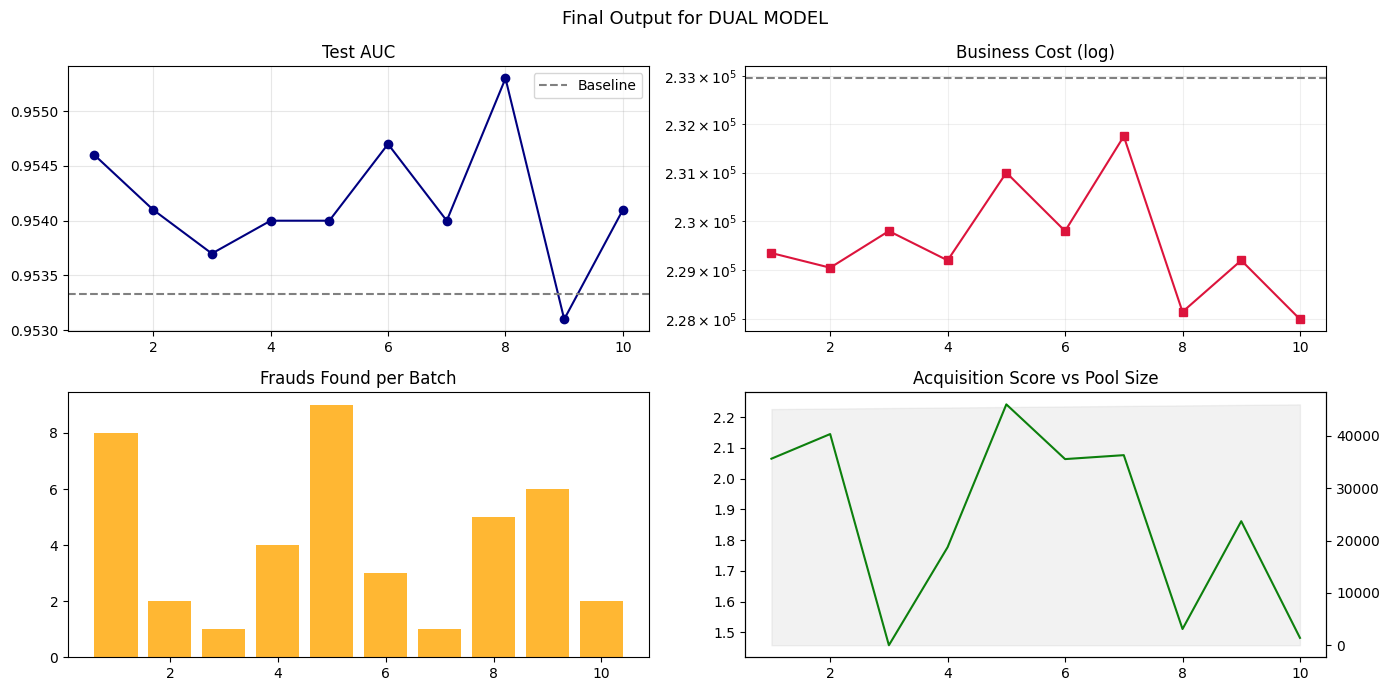


✅ DUAL MODEL AL complete.

═════════════════════════════════════════════════════════════════
  STARTING TWEEDIE GRID SEARCH (p ∈ [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
═════════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.1)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.1)]:   0%|          | 0/10 [00:00<?, ?it/s]

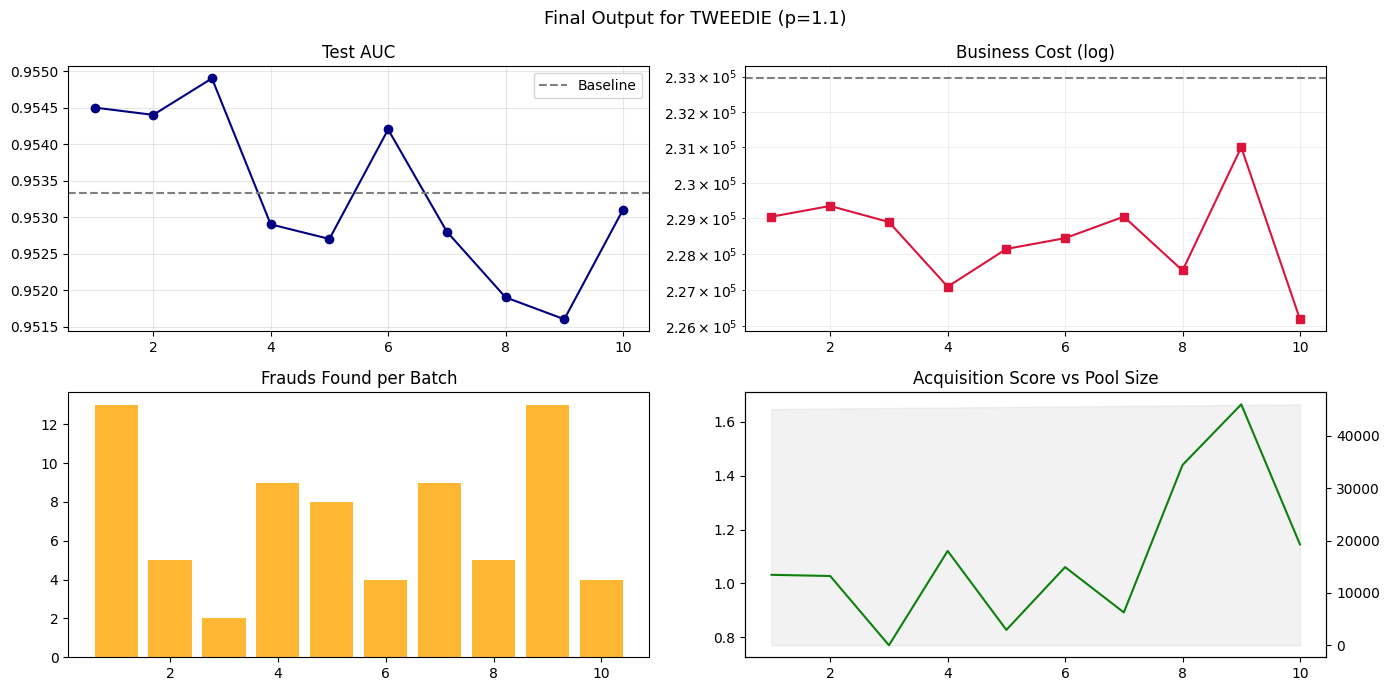


✅ TWEEDIE (p=1.1) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.2)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.2)]:   0%|          | 0/10 [00:00<?, ?it/s]

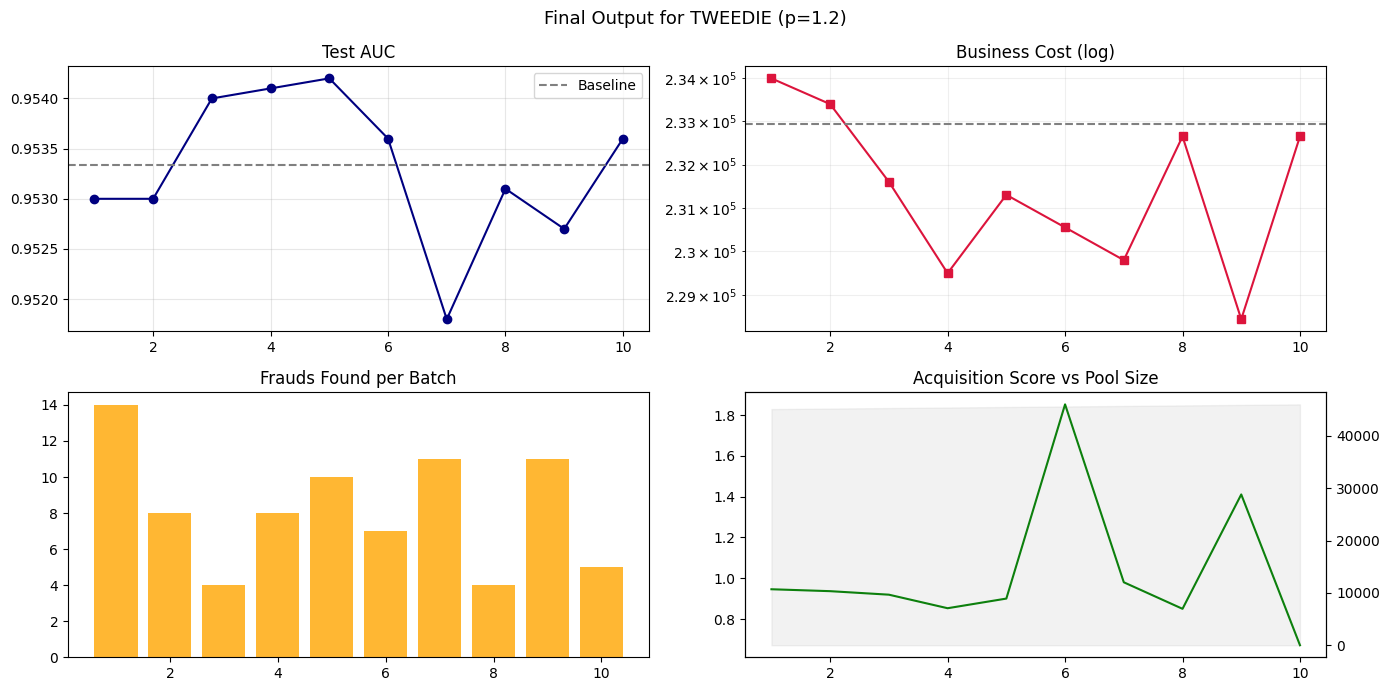


✅ TWEEDIE (p=1.2) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.3)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.3)]:   0%|          | 0/10 [00:00<?, ?it/s]

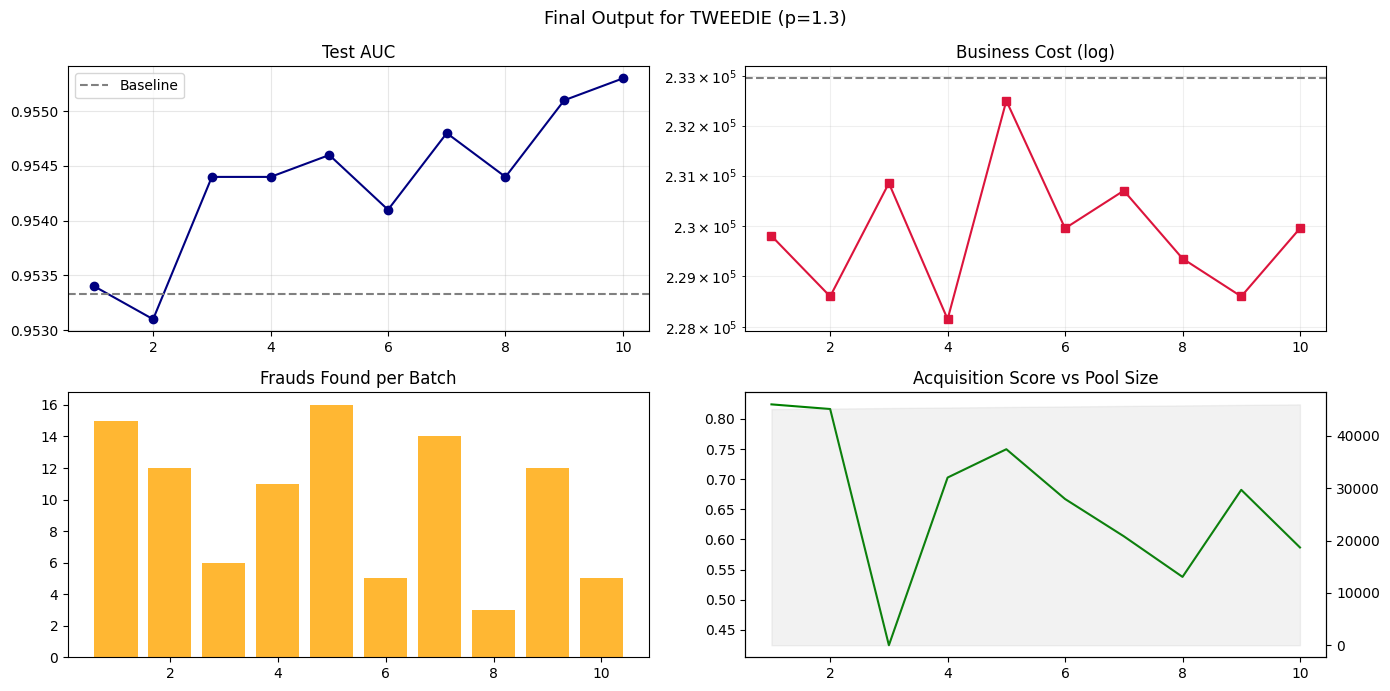


✅ TWEEDIE (p=1.3) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.4)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.4)]:   0%|          | 0/10 [00:00<?, ?it/s]

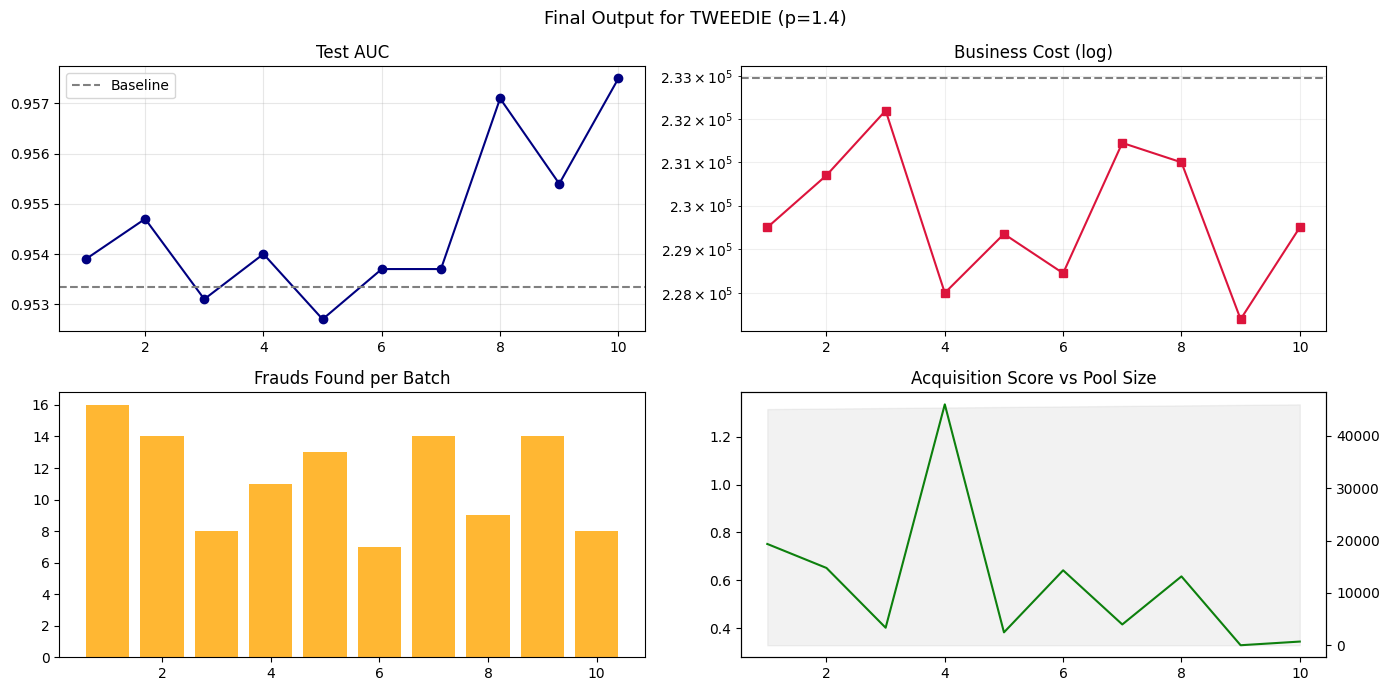


✅ TWEEDIE (p=1.4) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.5)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.5)]:   0%|          | 0/10 [00:00<?, ?it/s]

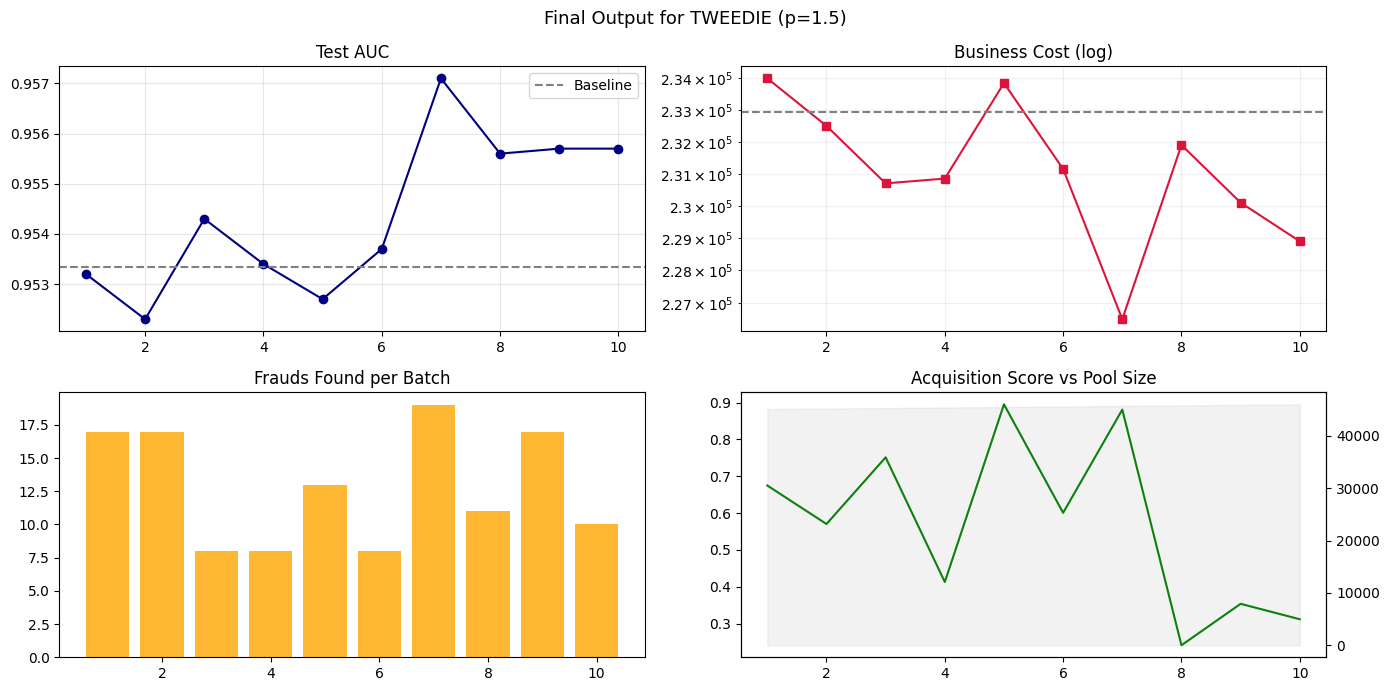


✅ TWEEDIE (p=1.5) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.6)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.6)]:   0%|          | 0/10 [00:00<?, ?it/s]

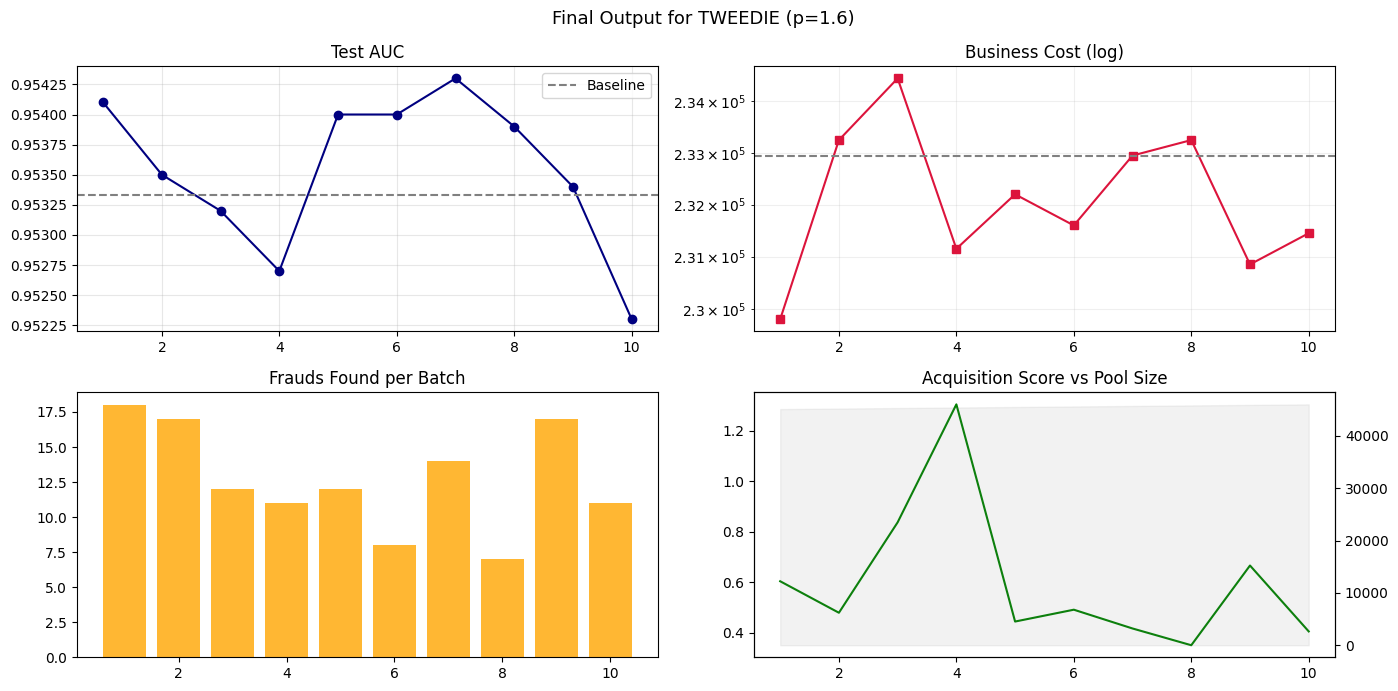


✅ TWEEDIE (p=1.6) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.7)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.7)]:   0%|          | 0/10 [00:00<?, ?it/s]

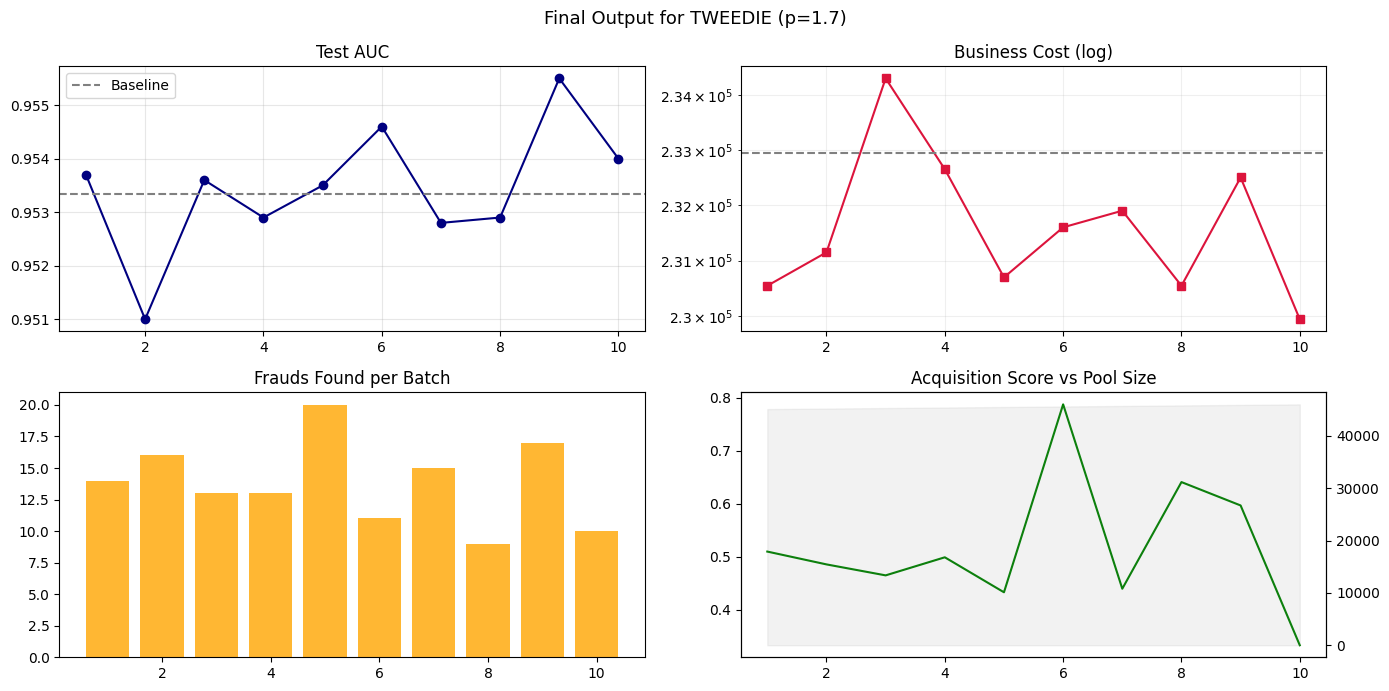


✅ TWEEDIE (p=1.7) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.8)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.8)]:   0%|          | 0/10 [00:00<?, ?it/s]

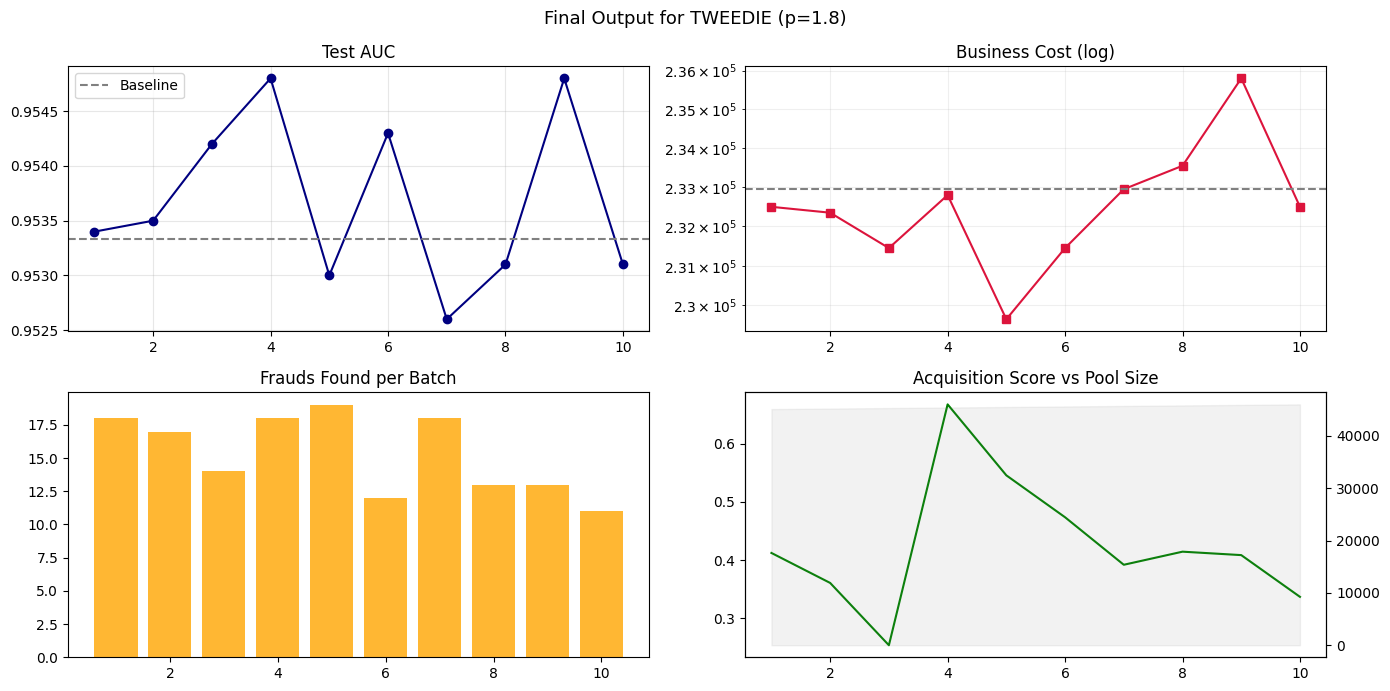


✅ TWEEDIE (p=1.8) AL complete.

═════════════════════════════════════════════════════════════════
  Strategy: TWEEDIE (p=1.9)
  10 loops × 100 queries
═════════════════════════════════════════════════════════════════



AL [TWEEDIE (p=1.9)]:   0%|          | 0/10 [00:00<?, ?it/s]

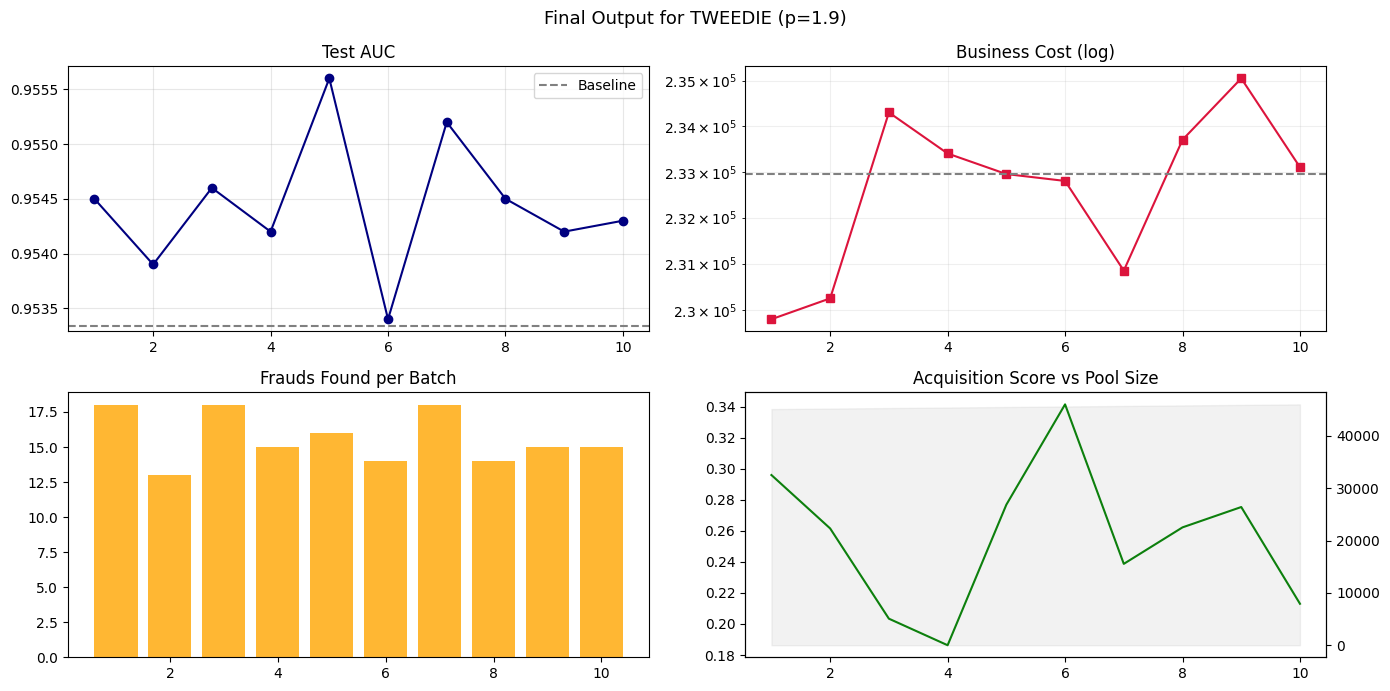


✅ TWEEDIE (p=1.9) AL complete.

═════════════════════════════════════════════════════════════════
  TWEEDIE GRID SEARCH RESULTS
═════════════════════════════════════════════════════════════════
                  auc  biz_cost  precision  recall      f1
model                                                     
Tweedie p=1.1  0.9531  226200.0     0.1866     1.0  0.3145
Tweedie p=1.2  0.9536  232650.0     0.1817     1.0  0.3075
Tweedie p=1.3  0.9553  229950.0     0.1837     1.0  0.3104
Tweedie p=1.4  0.9575  229500.0     0.1840     1.0  0.3109
Tweedie p=1.5  0.9557  228900.0     0.1845     1.0  0.3115
Tweedie p=1.6  0.9523  231450.0     0.1826     1.0  0.3088
Tweedie p=1.7  0.9540  229950.0     0.1837     1.0  0.3104
Tweedie p=1.8  0.9531  232500.0     0.1818     1.0  0.3077
Tweedie p=1.9  0.9543  233100.0     0.1814     1.0  0.3071

🏆 Best Tweedie p = 1.1 (Lowest Business Cost: 226,200)


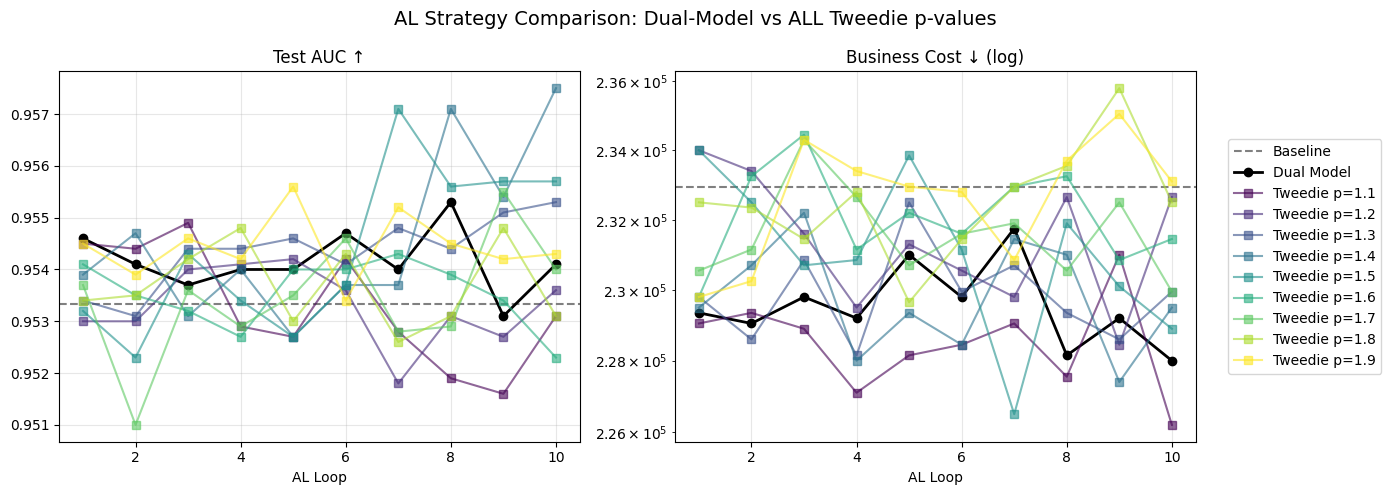

Plot saved → al_strategy_comparison_all_p.png


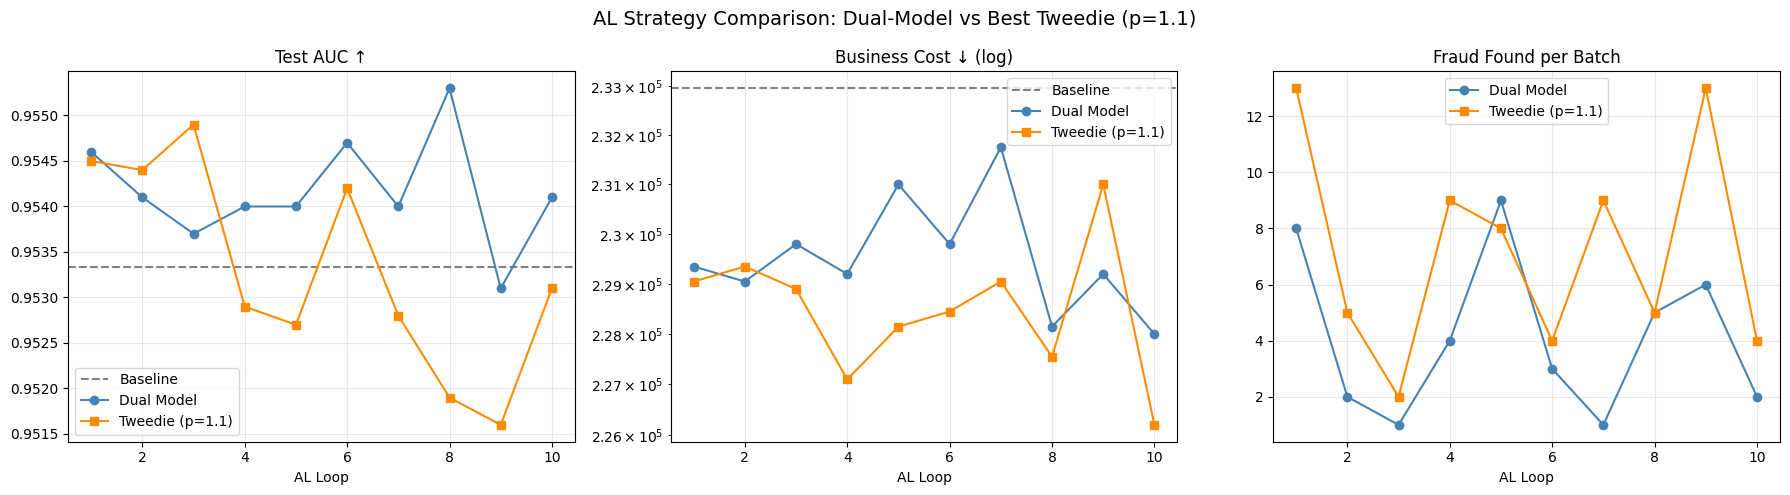

Plot saved → al_strategy_comparison_best_p.png

────────────────────────────────────────────────────────────────────────────────
  FINAL SUMMARY — c2_test set
────────────────────────────────────────────────────────────────────────────────
                              auc  biz_cost  precision  recall      f1
model                                                                 
Baseline                   0.9533  232950.0     0.1815     1.0  0.3072
AL — Dual Model            0.9541  228000.0     0.1852     1.0  0.3125
AL — Tweedie (Best p=1.1)  0.9531  226200.0     0.1866     1.0  0.3145
────────────────────────────────────────────────────────────────────────────────

  AL — Dual Model                      ΔAUC=+0.0008  ΔCost=-4,950 ✅

  AL — Tweedie (Best p=1.1)            ΔAUC=-0.0002  ΔCost=-6,750 ✅

[Analysis] Training final LightGBM Tweedie and Severity models...

[Analysis] Running analyze_payout_strategies (using Tweedie p=1.1)...

Total Actual Payout: $64,639,737.90

--- Financ

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  COMPLETE SELF-CONTAINED SCRIPT
#  Insurance Fraud Detection — Active Learning with Dual Model & Tweedie Grid Search
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 1 — IMPORTS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────

import os, json, warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm          # swap for tqdm.tqdm if not in Jupyter
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# ── User config ───────────────────────────────────────────────────────────────
DATA_CSV        = "synthetic_insurance_claims_with_fraud_3%_label.csv"  # ← SET THIS
TARGET_COL      = "fraud_label"
SUM_INSURED_COL = "sum_insured"

COST_TP         = 100
COST_FP         = 150
COST_TN         = 0

BEST_PARAMS_JSON = "best_params.json"   # ← path to your existing Optuna output

# Active Learning
N_AL_LOOPS         = 10
N_QUERY_PER_LOOP   = 100
N_SUBSAMPLE        = 2000
EARLY_STOPPING     = 50

# Hybrid AL
N_CANDIDATES_PER_STRAT = 200
N_MAX_INTERSECT        = 100

# Tweedie Grid Search Parameters
TWEEDIE_POWERS_TO_TEST = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]  # Grid search space for p

# Output paths
DUAL_MODEL_CSV        = "al_queried_labels_dual_model.csv"
DUAL_MODEL_PATH       = "al_dual_model_booster.json"
BASELINE_MODEL_PATH   = "baseline_model.json"
FINAL_NSL_MODEL_PATH  = "nonsequential_final_model.json"

print("✅ Config loaded.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 2 — LOAD DATA & SPLITS
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_CSV).drop(columns=["fraud_probability_score"], errors="ignore")

# Fix NaN labels
if df[TARGET_COL].isnull().any():
    df[TARGET_COL] = df[TARGET_COL].fillna(0).astype(int)
else:
    df[TARGET_COL] = df[TARGET_COL].astype(int)

print(f"Loaded {len(df):,} rows | fraud={df[TARGET_COL].mean()*100:.2f}%")

# ── labeled (65k) / unlabeled (30k) ──────────────────────────────────────────
df_labeled, df_unlabeled = train_test_split(
    df, test_size=30000, random_state=42, stratify=df[TARGET_COL]
)
print(f"Labeled: {len(df_labeled):,} | Unlabeled: {len(df_unlabeled):,}")

# ── Case 1 splits (all from labeled) ─────────────────────────────────────────
c1_train_data, c1_val_data = train_test_split(
    df_labeled, test_size=20000, random_state=42, stratify=df_labeled[TARGET_COL]
)
c1_test_data, c1_val_data = train_test_split(
    c1_val_data, test_size=10000, random_state=42, stratify=c1_val_data[TARGET_COL]
)

# ── Case 2 splits (test from unlabeled pool) ──────────────────────────────────
c2_train_data, c2_val_data = train_test_split(
    df_labeled, test_size=20000, random_state=42, stratify=df_labeled[TARGET_COL]
)
c2_test_data, df_remaining_unlabeled = train_test_split(
    df_unlabeled, train_size=10000,
    stratify=df_unlabeled[TARGET_COL], random_state=42
)

print(f"c1_train={len(c1_train_data):,} | c1_val={len(c1_val_data):,} | c1_test={len(c1_test_data):,}")
print(f"c2_test={len(c2_test_data):,} | unlabeled pool={len(df_remaining_unlabeled):,}")

# ── Pre-shuffle unlabeled pool (non-overlapping chunks across AL loops) ───────
rng            = np.random.default_rng(seed=42)
shuffled_order = rng.permutation(len(df_remaining_unlabeled))
df_remaining_unlabeled_pool = (
    df_remaining_unlabeled.copy().iloc[shuffled_order].reset_index(drop=True)
)

# ── Oracle (unlabeled rows kept with their true labels for simulated labelling)
df_unlabeled_oracle    = df_unlabeled.copy()
unlabeled_oracle_join_cols = [
    c for c in df_remaining_unlabeled_pool.columns if c != TARGET_COL
]

assert N_SUBSAMPLE * N_AL_LOOPS <= len(df_remaining_unlabeled_pool), \
    f"Pool too small: need {N_SUBSAMPLE*N_AL_LOOPS:,} rows but have {len(df_remaining_unlabeled_pool):,}"

print("✅ Data splits ready.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 3 — HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def compute_business_cost(y_true, y_pred_proba, sum_insured_vals,
                           threshold=0.5, cost_tp=COST_TP, cost_fp=COST_FP):
    """FN = 0.9 × sum_insured (missed fraud payout). Lower is better."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    cost   = np.zeros(len(y_true), dtype=np.float64)
    cost[(y_pred == 1) & (y_true == 1)] = cost_tp
    cost[(y_pred == 1) & (y_true == 0)] = cost_fp
    fn_mask = (y_pred == 0) & (y_true == 1)
    cost[fn_mask] = 0.9 * np.maximum(sum_insured_vals[fn_mask], 0)
    return float(np.sum(cost))


def make_sample_weights(y_train_fold, si_train_fold):
    """Fraud rows → weight = 0.9 × sum_insured; non-fraud → COST_FP."""
    weights = np.where(
        y_train_fold == 1,
        0.9 * np.maximum(si_train_fold, 0),
        COST_FP
    ).astype(np.float64)
    weights = np.maximum(weights, 1e-6)
    return weights / weights.mean()


def business_cost_custom_metric(y_proba, dtrain, si_vals, threshold):
    y_true = dtrain.get_label()
    cost   = compute_business_cost(y_true, y_proba, si_vals, threshold=threshold)
    return "business_cost", cost / max(len(y_true), 1)


def build_and_train_model(params, n_estimators, threshold,
                            X_train, y_train, si_train):
    """Train XGBoost booster with business-cost early stopping."""
    sw     = make_sample_weights(y_train, si_train)
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=sw)
    dval   = xgb.DMatrix(X_train, label=y_train)   # use train as ES proxy

    def _cost_eval(y_proba, dtrain_inner, _si=si_train, _th=threshold):
        return business_cost_custom_metric(y_proba, dtrain_inner, _si, _th)

    xgb_train_params = {
        "objective"  : "binary:logistic",
        "tree_method": "hist",
        "seed"       : 42,
        "verbosity"  : 0,
        **params,
    }
    booster = xgb.train(
        xgb_train_params,
        dtrain,
        num_boost_round       = n_estimators,
        evals                 = [(dval, "train")],
        custom_metric         = _cost_eval,
        early_stopping_rounds = EARLY_STOPPING,
        maximize              = False,
        verbose_eval          = False,
    )
    return booster


def load_params_from_json(json_path):
    with open(json_path) as f:
        raw = json.load(f)
    params       = {k: v for k, v in raw.items() if not k.startswith("_")}
    threshold    = params.pop("threshold", 0.5)
    n_estimators = params.pop("n_estimators", 300)
    return params, n_estimators, threshold


def evaluate_model(booster, dmat, y_true, si_vals, threshold, label, verbose=True):
    y_proba      = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred       = (y_proba >= threshold).astype(int)
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)

    if verbose:
        print(f"\n{'═'*62}\n  {label}\n{'═'*62}")
        print(f"  Threshold : {threshold:.4f} | AUC: {auc:.4f}")
        print(f"  Biz cost  : {biz_cost:>12,.2f}  (per row: {cost_per_row:,.4f})")
        print(f"  TP/FP/TN/FN: {tp}/{fp}/{tn}/{fn}")
        print(f"  Precision : {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
        print(f"{'═'*62}")

    return dict(model=label, auc=round(auc,4), biz_cost=round(biz_cost,2),
                cost_per_row=round(cost_per_row,4), tp=tp, fp=fp, tn=tn, fn=fn,
                precision=round(precision,4), recall=round(recall,4), f1=round(f1,4))


print("✅ Helper functions defined.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 4 — LOAD HYPERPARAMETERS FROM best_params.json
# ─────────────────────────────────────────────────────────────────────────────

xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

xgb_params["objective"]   = "binary:logistic"
xgb_params["tree_method"] = "hist"
xgb_params["seed"]        = 42

print(f"[Params] Loaded from '{BEST_PARAMS_JSON}'")
print(f"  Threshold    : {THRESHOLD:.4f}")
print(f"  N_ESTIMATORS : {N_ESTIMATORS}")
for k, v in xgb_params.items():
    print(f"  {k:<25} = {v}")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 5 — BASELINE MODEL
# ─────────────────────────────────────────────────────────────────────────────

X_pool_train  = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_train  = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool_train = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

print("\n[Baseline] Training …")
baseline_model = build_and_train_model(
    xgb_params, N_ESTIMATORS, THRESHOLD,
    X_pool_train, y_pool_train, si_pool_train
)
baseline_model.save_model(BASELINE_MODEL_PATH)

X_c2_test  = c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_c2_test  = c2_test_data[TARGET_COL].values.astype(np.int32)
si_c2_test = c2_test_data[SUM_INSURED_COL].values.astype(np.float64)

baseline_proba = baseline_model.predict(
    xgb.DMatrix(X_c2_test),
    iteration_range=(0, baseline_model.best_iteration + 1)
)
baseline_cost = compute_business_cost(y_c2_test, baseline_proba, si_c2_test, THRESHOLD)
baseline_auc  = roc_auc_score(y_c2_test, baseline_proba)

print(f"[Baseline] AUC={baseline_auc:.4f} | Business cost={baseline_cost:,.0f}")
print(f"✅ Baseline model saved → {BASELINE_MODEL_PATH}")

FEATURE_COLS = [c for c in df_labeled.columns
                if c not in [TARGET_COL, SUM_INSURED_COL]]


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 6 — DUAL-MODEL & TWEEDIE HELPERS
# ─────────────────────────────────────────────────────────────────────────────

# ── Dual Model ────────────────────────────────────────────────────────────────
def train_severity_model(X_train_df, y_arr, si_arr):
    mask   = (y_arr == 1) & (si_arr > 0.0)
    if mask.sum() < 10:
        return None

    X_sev  = X_train_df[mask]
    y_sev  = si_arr[mask]

    model  = lgb.LGBMRegressor(
        objective="gamma", learning_rate=0.05,
        num_leaves=31, min_child_samples=5,
        n_estimators=300, verbosity=-1, random_state=42,
    )
    model.fit(X_sev, y_sev)
    return model

def dual_model_query(X_unlabeled_df, si_vals, freq_proba, sev_model, n_query):
    e_sev      = sev_model.predict(X_unlabeled_df)
    e_sev      = np.maximum(e_sev, 1.0)
    e_loss     = freq_proba * e_sev
    uncertainty = 1.0 - np.abs(2.0 * freq_proba - 1.0)
    scores     = uncertainty * np.log1p(e_loss)
    return np.argsort(-scores)[:n_query], scores

# ── Tweedie Model ─────────────────────────────────────────────────────────────
def make_tweedie_target(y_arr, si_arr):
    return y_arr.astype(np.float64) * np.maximum(si_arr, 0.0)

def train_tweedie_model(X_train_df, y_arr, si_arr, p):
    payout = make_tweedie_target(y_arr, si_arr)
    if (payout > 0).sum() < 5:
        return None
    model = lgb.LGBMRegressor(
        objective="tweedie", tweedie_variance_power=p,
        learning_rate=0.05, num_leaves=31, min_child_samples=5,
        n_estimators=300, verbosity=-1, random_state=42,
    )
    model.fit(X_train_df, payout)
    return model

def tweedie_query(X_unlabeled_df, freq_proba, tw_model, n_query):
    tw_pred    = np.maximum(tw_model.predict(X_unlabeled_df), 0.0)
    uncertainty = 1.0 - np.abs(2.0 * freq_proba - 1.0)
    scores     = uncertainty * np.log1p(tw_pred)
    return np.argsort(-scores)[:n_query], scores

print("✅ Dual-Model & Tweedie helpers defined.")


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 7 — GENERIC AL LOOP (REMOVED clear_output to preserve plots)
# ─────────────────────────────────────────────────────────────────────────────

def run_al_loop(strategy_name, output_csv, model_path, tweedie_power=None):
    assert strategy_name in ("dual_model", "tweedie")

    if os.path.exists(output_csv):
        os.remove(output_csv)

    # Reset to baseline state
    current_model    = baseline_model
    X_cur            = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
    y_cur            = c1_train_data[TARGET_COL].values.astype(np.int32)
    si_cur           = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

    al_log = []
    strat_label = f"TWEEDIE (p={tweedie_power})" if strategy_name == "tweedie" else "DUAL MODEL"

    print(f"\n{'═'*65}")
    print(f"  Strategy: {strat_label}")
    print(f"  {N_AL_LOOPS} loops × {N_QUERY_PER_LOOP} queries")
    print(f"{'═'*65}\n")

    for al_loop in tqdm(range(N_AL_LOOPS), desc=f"AL [{strat_label}]"):
        s, e      = al_loop * N_SUBSAMPLE, (al_loop + 1) * N_SUBSAMPLE
        df_chunk  = df_remaining_unlabeled_pool.drop(columns=[TARGET_COL]).iloc[s:e]
        X_unlab   = df_chunk.drop(columns=[SUM_INSURED_COL])
        si_chunk  = df_chunk[SUM_INSURED_COL].values.astype(np.float64)

        # Step 1 — Fraud probabilities from XGBoost classifier
        freq_proba = current_model.predict(
            xgb.DMatrix(X_unlab),
            iteration_range=(0, current_model.best_iteration + 1)
        )

        # Step 2 — Train auxiliary model & pick query indices
        if strategy_name == "dual_model":
            sev_model                 = train_severity_model(X_cur, y_cur, si_cur)
            query_idx, scores         = dual_model_query(X_unlab, si_chunk,
                                                          freq_proba, sev_model,
                                                          N_QUERY_PER_LOOP)
        else:  # tweedie
            tw_model                  = train_tweedie_model(X_cur, y_cur, si_cur, tweedie_power)
            query_idx, scores         = tweedie_query(X_unlab, freq_proba,
                                                       tw_model, N_QUERY_PER_LOOP)

        # Step 3 — Oracle lookup (simulated human labelling)
        query_df                       = df_chunk.iloc[query_idx].copy()
        query_df["al_pred_proba"]      = freq_proba[query_idx]
        query_df["al_uncertainty"]     = scores[query_idx]
        merge_cols                     = [c for c in unlabeled_oracle_join_cols
                                          if c in query_df.columns]
        newly_labeled = pd.merge(
            query_df,
            df_unlabeled_oracle[unlabeled_oracle_join_cols + [TARGET_COL]],
            on=merge_cols, how="left"
        )
        assert newly_labeled[TARGET_COL].notna().all(), \
            f"Loop {al_loop+1}: oracle lookup failed."

        # Step 4 — Save to CSV
        save_df    = newly_labeled[df_labeled.columns.tolist()
                                   + ["al_pred_proba", "al_uncertainty"]].copy()
        save_df.to_csv(output_csv, mode="a",
                       header=not os.path.exists(output_csv), index=False)

        # Step 5 — Expand labeled pool
        X_new  = newly_labeled[FEATURE_COLS].values
        y_new  = newly_labeled[TARGET_COL].values.astype(np.int32)
        si_new = newly_labeled[SUM_INSURED_COL].values.astype(np.float64)
        X_cur  = pd.concat([X_cur, pd.DataFrame(X_new, columns=FEATURE_COLS)],
                            ignore_index=True)
        y_cur  = np.concatenate([y_cur,  y_new])
        si_cur = np.concatenate([si_cur, si_new])

        # Step 6 — Retrain XGBoost fraud classifier
        current_model = build_and_train_model(
            xgb_params, N_ESTIMATORS, THRESHOLD, X_cur, y_cur, si_cur
        )

        # Step 7 — Evaluate on c2_test
        test_proba = current_model.predict(
            xgb.DMatrix(X_c2_test),
            iteration_range=(0, current_model.best_iteration + 1)
        )
        test_cost  = compute_business_cost(y_c2_test, test_proba, si_c2_test, THRESHOLD)
        test_auc   = roc_auc_score(y_c2_test, test_proba)

        loop_stats = dict(
            loop=al_loop+1, train_pool_size=len(y_cur),
            unlabeled_remaining=len(df_remaining_unlabeled_pool) - e,
            fraud_in_query=int(y_new.sum()),
            mean_score=round(float(scores[query_idx].mean()), 4),
            test_auc=round(test_auc, 4),
            test_business_cost=round(test_cost, 2),
        )
        al_log.append(loop_stats)

    current_model.save_model(model_path)
    df_log = pd.DataFrame(al_log)

    # Generate final static plot for this strategy without clearing prior outputs
    dt = df_log
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle(f"Final Output for {strat_label}", fontsize=13)
    axes[0,0].plot(dt["loop"], dt["test_auc"], "o-", color="navy")
    axes[0,0].axhline(baseline_auc, ls="--", color="gray", label="Baseline")
    axes[0,0].set_title("Test AUC"); axes[0,0].legend(); axes[0,0].grid(alpha=.3)
    axes[0,1].plot(dt["loop"], dt["test_business_cost"], "s-", color="crimson")
    axes[0,1].axhline(baseline_cost, ls="--", color="gray")
    axes[0,1].set_yscale("log"); axes[0,1].set_title("Business Cost (log)")
    axes[0,1].grid(True, which="both", alpha=.2)
    axes[1,0].bar(dt["loop"], dt["fraud_in_query"], color="orange", alpha=.8)
    axes[1,0].set_title("Frauds Found per Batch")
    ax2 = axes[1,1].twinx()
    axes[1,1].plot(dt["loop"], dt["mean_score"], color="green")
    ax2.fill_between(dt["loop"], dt["train_pool_size"], color="gray", alpha=.1)
    axes[1,1].set_title("Acquisition Score vs Pool Size")
    plt.tight_layout(); plt.show()

    print(f"\n✅ {strat_label} AL complete.")
    return df_log, current_model


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 8 — RUN STRATEGIES & TWEEDIE GRID SEARCH
# ─────────────────────────────────────────────────────────────────────────────

dtest_c2 = xgb.DMatrix(X_c2_test)

# 1. Run Dual Model
df_log_dual, final_model_dual = run_al_loop("dual_model", DUAL_MODEL_CSV, DUAL_MODEL_PATH)

# 2. Run Tweedie Grid Search
print(f"\n{'═'*65}")
print(f"  STARTING TWEEDIE GRID SEARCH (p ∈ {TWEEDIE_POWERS_TO_TEST})")
print(f"{'═'*65}")

tweedie_results = {}
best_tw_cost    = float('inf')
best_tw_p       = None

for p in TWEEDIE_POWERS_TO_TEST:
    csv_path = f"al_tweedie_p{p}.csv"
    mod_path = f"al_tweedie_p{p}.json"

    # Run AL (The loop now automatically generates the final plot at the end)
    df_log, model = run_al_loop("tweedie", csv_path, mod_path, tweedie_power=p)

    # Evaluate final model for this p
    stats = evaluate_model(model, dtest_c2, y_c2_test, si_c2_test, THRESHOLD, f"Tweedie p={p}", verbose=False)

    tweedie_results[p] = {
        'log': df_log,
        'model': model,
        'stats': stats,
        'mod_path': mod_path
    }

    if stats['biz_cost'] < best_tw_cost:
        best_tw_cost = stats['biz_cost']
        best_tw_p    = p

print(f"\n{'═'*65}")
print("  TWEEDIE GRID SEARCH RESULTS")
print(f"{'═'*65}")
grid_summary = pd.DataFrame([res['stats'] for res in tweedie_results.values()]).set_index('model')
print(grid_summary[["auc", "biz_cost", "precision", "recall", "f1"]].to_string())
print(f"\n🏆 Best Tweedie p = {best_tw_p} (Lowest Business Cost: {best_tw_cost:,.0f})")

# 3. Setup final best variables
df_log_tw      = tweedie_results[best_tw_p]['log']
TWEEDIE_PATH   = tweedie_results[best_tw_p]['mod_path']
stats_tw       = tweedie_results[best_tw_p]['stats']
stats_tw['model'] = f"AL — Tweedie (Best p={best_tw_p})"

booster_baseline = xgb.Booster(); booster_baseline.load_model(BASELINE_MODEL_PATH)
booster_dual     = xgb.Booster(); booster_dual.load_model(DUAL_MODEL_PATH)
booster_tw       = xgb.Booster(); booster_tw.load_model(TWEEDIE_PATH)

stats_bl = evaluate_model(booster_baseline, dtest_c2, y_c2_test, si_c2_test, THRESHOLD, "Baseline", verbose=False)
stats_dm = evaluate_model(booster_dual,     dtest_c2, y_c2_test, si_c2_test, THRESHOLD, "AL — Dual Model", verbose=False)

# ── Progression comparison plot (ALL p-values) ────────────────────────────────
loops = df_log_dual["loop"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AL Strategy Comparison: Dual-Model vs ALL Tweedie p-values", fontsize=14)

axes[0].axhline(baseline_auc, ls="--", color="gray", lw=1.5, label="Baseline")
axes[1].axhline(baseline_cost, ls="--", color="gray", lw=1.5, label="Baseline")

axes[0].plot(loops, df_log_dual["test_auc"], "o-", color="black", label="Dual Model", linewidth=2)
axes[1].plot(loops, df_log_dual["test_business_cost"], "o-", color="black", label="Dual Model", linewidth=2)

cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, len(TWEEDIE_POWERS_TO_TEST))]

for idx, p in enumerate(TWEEDIE_POWERS_TO_TEST):
    df_p = tweedie_results[p]['log']
    axes[0].plot(loops, df_p["test_auc"], "s-", color=colors[idx], label=f"Tweedie p={p}", alpha=0.6)
    axes[1].plot(loops, df_p["test_business_cost"], "s-", color=colors[idx], label=f"Tweedie p={p}", alpha=0.6)

axes[1].set_yscale("log")
axes[0].set_title("Test AUC ↑"); axes[0].set_xlabel("AL Loop"); axes[0].grid(True, alpha=.3)
axes[1].set_title("Business Cost ↓ (log)"); axes[1].set_xlabel("AL Loop"); axes[1].grid(True, alpha=.3)

# Place legend outside the plot
axes[1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout()
plt.savefig("al_strategy_comparison_all_p.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → al_strategy_comparison_all_p.png")


# ── Progression comparison plot (Best p vs Dual) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"AL Strategy Comparison: Dual-Model vs Best Tweedie (p={best_tw_p})", fontsize=14)

for ax, metric, title, best_fn in zip(
    axes,
    ["test_auc", "test_business_cost", "fraud_in_query"],
    ["Test AUC ↑", "Business Cost ↓ (log)", "Fraud Found per Batch"],
    [max, min, sum],
):
    if metric != "fraud_in_query":
        ax.axhline(baseline_auc if "auc" in metric else baseline_cost,
                   ls="--", color="gray", lw=1.5, label="Baseline")
    ax.plot(loops, df_log_dual[metric],   "o-", color="steelblue",  label="Dual Model")
    ax.plot(loops, df_log_tw[metric],     "s-", color="darkorange", label=f"Tweedie (p={best_tw_p})")
    if "cost" in metric:
        ax.set_yscale("log")
    ax.set_title(title); ax.set_xlabel("AL Loop")
    ax.legend(); ax.grid(True, alpha=.3)

plt.tight_layout()
plt.savefig("al_strategy_comparison_best_p.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → al_strategy_comparison_best_p.png")

# ── Summary table ─────────────────────────────────────────────────────────────
df_summary = pd.DataFrame([stats_bl, stats_dm, stats_tw]).set_index("model")
print(f"\n{'─'*80}")
print("  FINAL SUMMARY — c2_test set")
print(f"{'─'*80}")
print(df_summary[["auc","biz_cost","precision","recall","f1"]].to_string())
print(f"{'─'*80}")

for s in [stats_dm, stats_tw]:
    d_cost = s["biz_cost"] - stats_bl["biz_cost"]
    d_auc  = s["auc"]      - stats_bl["auc"]
    icon   = "✅" if d_cost < 0 else "❌"
    print(f"\n  {s['model']:35s}  ΔAUC={d_auc:+.4f}  ΔCost={d_cost:+,.0f} {icon}")

# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 9 — PAYOUT STRATEGY ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import spearmanr

def analyze_payout_strategies(X_eval, y_true_label, true_sum_insured, true_actual_payout,
                              tweedie_model, dual_freq_model, dual_sev_model):
    """Analyzes prediction bias (over/underestimation) and rank-ordering capability."""

    # 1. Generate Predictions
    naive_payout  = true_sum_insured
    tweedie_preds = np.maximum(tweedie_model.predict(X_eval), 0.0)

    freq_preds = dual_freq_model.predict(X_eval)
    sev_preds  = np.maximum(dual_sev_model.predict(X_eval), 1.0)
    dual_preds = freq_preds * sev_preds

    total_actual = true_actual_payout.sum()

    # --- EVALUATION 1: Financial Bias (Over/Underestimation) ---
    def calc_bias(preds):
        """Calculates % difference from actual to show directional error."""
        diff = preds.sum() - total_actual
        pct = (diff / total_actual) * 100 if total_actual > 0 else 0
        direction = "Overestimated" if diff > 0 else "Underestimated"
        return direction, pct

    dir_naive, pct_naive = calc_bias(naive_payout)
    dir_tw, pct_tw       = calc_bias(tweedie_preds)
    dir_dual, pct_dual   = calc_bias(dual_preds)

    print(f"Total Actual Payout: ${total_actual:,.2f}\n")
    print("--- Financial Bias (Predicted vs Actual Total) ---")
    print(f"Raw Sum Insured : {dir_naive} by {abs(pct_naive):.1f}%")
    print(f"Tweedie Model   : {dir_tw} by {abs(pct_tw):.1f}%")
    print(f"Dual Model      : {dir_dual} by {abs(pct_dual):.1f}%\n")

    # --- EVALUATION 2: Rank Correlation ---
    rank_naive, _   = spearmanr(true_actual_payout, naive_payout)
    rank_tweedie, _ = spearmanr(true_actual_payout, tweedie_preds)
    rank_dual, _    = spearmanr(true_actual_payout, dual_preds)

    print("--- Ranking Accuracy (Spearman Rank w/ True Payout) ---")
    print(f"Raw Sum Insured : {rank_naive:.4f}")
    print(f"Tweedie Model   : {rank_tweedie:.4f}")
    print(f"Dual Model      : {rank_dual:.4f}\n")

    # --- EVALUATION 3: Threat Identification ---
    df_analysis = pd.DataFrame({
        'True_Payout': true_actual_payout,
        'Sum_Insured': naive_payout,
        'Tweedie_Pred': tweedie_preds,
        'Dual_Pred': dual_preds
    })

    # Rank dataset globally (ascending=False puts highest predictions in top percentiles)
    df_analysis['Rank_Sum_Insured'] = df_analysis['Sum_Insured'].rank(pct=True, ascending=False)
    df_analysis['Rank_Tweedie']     = df_analysis['Tweedie_Pred'].rank(pct=True, ascending=False)
    df_analysis['Rank_Dual']        = df_analysis['Dual_Pred'].rank(pct=True, ascending=False)

    # Filter to actual most expensive claims (top 5%)
    top_5_threshold = np.percentile(true_actual_payout, 95)
    top_claims = df_analysis[df_analysis['True_Payout'] >= top_5_threshold]

    print("--- Threat Identification (Avg Global Queue Position for Top 5% True Claims) ---")
    print(f"Sum Insured : Top {top_claims['Rank_Sum_Insured'].mean():.2%}")
    print(f"Tweedie     : Top {top_claims['Rank_Tweedie'].mean():.2%}")
    print(f"Dual Model  : Top {top_claims['Rank_Dual'].mean():.2%}")

    return df_analysis


# ─────────────────────────────────────────────────────────────────────────────
#  EXECUTE ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

# 1. Define true financial loss (Fraud rows = 0.9 * sum_insured, else 0)
true_actual_payout = y_c2_test * 0.9 * si_c2_test

# 2. Train final models on baseline pool (Using best_tw_p discovered in Grid Search)
print("\n[Analysis] Training final LightGBM Tweedie and Severity models...")
final_sev_model = train_severity_model(X_pool_train, y_pool_train, si_pool_train)
final_tw_model  = train_tweedie_model(X_pool_train, y_pool_train, si_pool_train, best_tw_p)

# 3. XGBoost wrapper for DataFrame compatibility
class XGBDataFrameWrapper:
    def __init__(self, booster):
        self.booster = booster

    def predict(self, X):
        dmat = xgb.DMatrix(X)
        return self.booster.predict(dmat, iteration_range=(0, self.booster.best_iteration + 1))

wrapped_freq_model = XGBDataFrameWrapper(booster_dual)

# 4. Run evaluation
print(f"\n[Analysis] Running analyze_payout_strategies (using Tweedie p={best_tw_p})...\n")
df_analysis_results = analyze_payout_strategies(
    X_eval=X_c2_test,
    y_true_label=y_c2_test,
    true_sum_insured=si_c2_test,
    true_actual_payout=true_actual_payout,
    tweedie_model=final_tw_model,
    dual_freq_model=wrapped_freq_model,
    dual_sev_model=final_sev_model
)

# Research proposal -- Tweedie (FINAL CODE)

In [ ]:
# =============================================================================
# SECTION 1 – IMPORTS & CONFIGURATION
# =============================================================================
import random
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_tweedie_deviance
import xgboost as xgb

warnings.filterwarnings('ignore')

SEED = 42
TWEEDIE_P = 1.5
random.seed(SEED)
np.random.seed(SEED)

# =============================================================================
# SECTION 2 – SYNTHETIC DATA GENERATION (10k points)
# =============================================================================
def _poisson(lam):
    if lam <= 0:
        return 0
    L, k, p = math.exp(-lam), 0, 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1

def _gamma(mean, shape=1.2): # CHANGED: Fatter tail to trap MaxVar
    return random.gammavariate(shape, mean / shape)

def generate_uk_home_insurance_data(n_records=10000):
    """Generate synthetic home insurance data with Tweedie target."""
    data, true_lambdas, true_sev_means = [], [], []

    products = ['Buildings','Contents','Combined','Landlord','Premium Combined','Standard']
    occupations = {'retired':0.28,'housewife':0.08,'professional':0.22,
                   'white_collar':0.30,'skilled_worker':0.08,'other':0.04}
    property_types = {'Terraced':0.26,'Semi':0.24,'Flat':0.24,
                      'Detached':0.19,'Bungalow':0.07}
    urban_rural_dst = {'urban':0.83,'rural':0.17}

    for _ in range(n_records):
        policy_product = random.choice(products)
        tier = random.choices([1,2,3], weights=[0.35,0.50,0.15])[0]
        cust_occ = random.choices(list(occupations.keys()),
                                  weights=list(occupations.values()))[0]
        prop_type = random.choices(list(property_types.keys()),
                                   weights=list(property_types.values()))[0]

        rooms_cfg = {'Flat':([1,2,3,4],[0.25,0.45,0.25,0.05]),
                     'Terraced':([2,3,4,5],[0.15,0.55,0.25,0.05]),
                     'Semi':([2,3,4,5],[0.10,0.45,0.35,0.10]),
                     'Bungalow':([2,3,4],[0.35,0.50,0.15]),
                     'Detached':([3,4,5,6],[0.20,0.40,0.30,0.10])}
        no_of_rooms = random.choices(*rooms_cfg[prop_type])[0]

        base_si = {'Flat':200_000,'Terraced':300_000,'Semi':350_000,
                   'Bungalow':320_000,'Detached':500_000}
        sum_insured = int(base_si[prop_type] * random.uniform(0.7,1.8) / 50_000) * 50_000
        mkt_value   = int(sum_insured * random.uniform(1.1,1.8) / 10_000) * 10_000

        age_cfg = [('pre_1900',(125,200),0.20),('1900_1944',(80,124),0.25),
                   ('1945_1980',(44,79),0.28),('1981_2000',(24,43),0.15),
                   ('2001_2020',(4,23),0.10),('post_2020',(0,3),0.02)]
        _, ranges, wts = zip(*age_cfg)
        prop_age  = random.randint(*random.choices(ranges, weights=wts)[0])
        plumb_age = min(prop_age, random.randint(5,40))

        constr_mat = random.choices(['bricks','cement','wood','stone'],
                                    weights=[0.70,0.20,0.05,0.05])[0]
        roof_mat   = random.choices(['tiles','slate','cement','wood'],
                                    weights=[0.55,0.25,0.15,0.05])[0]

        occupants  = random.choices([1,2,3,4,5,6],[0.15,0.30,0.25,0.20,0.07,0.03])[0]
        guests     = random.choices([0,1,2],[0.92,0.06,0.02])[0]
        biz_use    = 'Y' if random.random()<0.05 else 'N'
        unocc_days = random.choices([0,30,60,90],[0.90,0.05,0.03,0.02])[0]
        stl        = 1 if random.random()<0.02 else 0
        owner_det  = random.choices(['owner','user','legal_lease','financier'],
                                    weights=[0.75,0.15,0.08,0.02])[0]

        flood   = random.choices([1,2,3,4,5],[0.40,0.30,0.20,0.07,0.03])[0]
        storm   = random.choices([1,2,3,4,5],[0.35,0.30,0.22,0.10,0.03])[0]
        nat_cal = random.choices([1,2,3,4,5],[0.45,0.28,0.18,0.07,0.02])[0]
        urb_rur = random.choices(list(urban_rural_dst.keys()),
                                 weights=list(urban_rural_dst.values()))[0]
        crime   = random.choices([1,2,3,4,5],
                    [0.15,0.30,0.35,0.15,0.05] if urb_rur=='urban'
                    else [0.40,0.35,0.18,0.05,0.02])[0]

        smart_h = 1 if random.random()<0.28 else 0
        fire_s  = 1 if random.random()<0.45 else 0
        sec_s   = 1 if random.random()<0.52 else 0

        cont_claims = random.choices([0,1,2,3],[0.82,0.12,0.04,0.02])[0]
        bld_claims  = random.choices([0,1,2,3],[0.85,0.10,0.03,0.02])[0]
        n_claims_5y = cont_claims + bld_claims

        apr      = 1 if random.random()<0.55 else 0
        prev_bld = 1 if random.random()<0.70 else 0
        prev_cne = 1 if random.random()<0.65 else 0
        cov_sel  = 1 if random.random()<0.70 else 0
        add_cov  = random.choice([0,5000,10000,15000,25000]) if cov_sel else 0
        prem_beh = int(random.triangular(60,100,85))

        # CHANGED: Stronger signal to noise ratio so Gini goes up
        rs = (0.35*flood + 0.30*storm + 0.20*nat_cal + 0.25*crime
              + 0.15*(prop_age/50) + 0.10*(plumb_age/30)
              - 0.10*sec_s - 0.08*fire_s + 0.10*(n_claims_5y/3))

        lam = 0.05 * math.exp(1.2 * rs) * (1.0 + 0.5 * math.sin(rs * 3.14))
        n_ev = _poisson(lam)
        sev_mean = sum_insured * 0.008 * math.exp(0.6 * rs) * random.uniform(0.7, 1.3)

        claim_amt = (round(sum(_gamma(sev_mean, 1.2) for _ in range(n_ev)), 2)
                     if n_ev > 0 else 0.0)

        true_lambdas.append(lam)
        true_sev_means.append(sev_mean)

        data.append({
            'claim_amount':claim_amt,'exposure':1.0,
            'policy_product':policy_product,'tier':tier,
            'coverage_selected':cov_sel,'additional_coverage_amount':add_cov,
            'cust_occupation':cust_occ,'property_type':prop_type,
            'sum_insured':sum_insured,'property_market_value':mkt_value,
            'property_age':prop_age,'construction_material':constr_mat,
            'roof_material':roof_mat,'no_of_rooms':no_of_rooms,
            'plumbing_elec_age':plumb_age,'occupants_count':occupants,
            'paying_guest_no':guests,'business_use':biz_use,
            'unoccupied_days':unocc_days,'short_term_letting':stl,
            'owner_details':owner_det,'urban_rural':urb_rur,
            'flood_risk':flood,'storm_risk':storm,
            'other_natural_calamities_risk':nat_cal,'crime_rate':crime,
            'smart_home':smart_h,'fire_safety_systems':fire_s,
            'security_systems':sec_s,'contents_claim_counts':cont_claims,
            'building_claim_count':bld_claims,'no_of_claims_5yr':n_claims_5y,
            'APR_FLAG':apr,'previous_insurance_buildings':prev_bld,
            'previous_insurance_cne':prev_cne,
            'premium_payment_behaviour':prem_beh,
        })

    df = pd.DataFrame(data)
    lam_arr = np.array(true_lambdas)
    sev_arr = np.array(true_sev_means)
    phi_per_obs      = 3.0 * np.sqrt(sev_arr) / (2.0 * np.sqrt(lam_arr))
    phi_true_analytical = float(np.median(phi_per_obs))
    meta = {'true_lambdas': lam_arr,
            'phi_true': phi_true_analytical,
            'p_true': TWEEDIE_P}
    return df, meta

# =============================================================================
# SECTION 3 – PREPROCESSING
# =============================================================================
def preprocess(df):
    cat_cols = ['policy_product','cust_occupation','property_type',
                'construction_material','roof_material','business_use',
                'owner_details','urban_rural']
    df_enc = pd.get_dummies(df.drop(columns=['exposure']), columns=cat_cols, drop_first=True)
    y    = df_enc['claim_amount'].values.astype(np.float32)
    feat = [c for c in df_enc.columns if c != 'claim_amount']
    X    = df_enc[feat].values.astype(np.float32)
    scaler = StandardScaler()
    X = scaler.fit_transform(X).astype(np.float32)
    return X, y, feat

# =============================================================================
# SECTION 4 – TWEEDIE UTILITIES
# =============================================================================
def estimate_phi(y, mu, p=TWEEDIE_P, eps=1e-10):
    """MLE estimator: phi = mean unit Tweedie deviance on held-out validation data."""
    mu = np.maximum(mu, eps)
    phi_hat = mean_tweedie_deviance(y, mu, power=p)
    return max(phi_hat, eps)

def zero_mass_calibration_error(y_true, mu_pred, phi, p=TWEEDIE_P, bins=10):
    lam    = implied_lambda(mu_pred, phi, p)
    p_zero = np.exp(-lam)
    order  = np.argsort(p_zero)
    p_zero, y_true = p_zero[order], y_true[order]
    n = len(y_true)
    errs = []
    for b in range(bins):
        lo, hi = int(b*n/bins), int((b+1)*n/bins)
        if hi - lo < 20:
            continue
        errs.append(abs(p_zero[lo:hi].mean() - (y_true[lo:hi]==0).mean()))
    return np.mean(errs)

def implied_lambda(mu_pred, phi, p=TWEEDIE_P):
    b = 2.0 - p
    return mu_pred ** b / (phi * b + 1e-8)

def lambda_rmse(true_lambda, pred_lambda):
    return np.sqrt(np.mean((true_lambda - pred_lambda) ** 2))

def lorenz_gini(y_true, mu_pred):
    order    = np.argsort(mu_pred)
    y_sorted = y_true[order]
    cum_loss = np.cumsum(y_sorted) / (y_sorted.sum() + 1e-12)
    n        = len(y_sorted)
    cum_pop  = np.arange(1, n+1) / n
    gini     = 1.0 - 2.0 * np.trapz(cum_loss, cum_pop)
    return cum_pop, cum_loss, gini

# =============================================================================
# SECTION 5 – XGBOOST ENSEMBLE
# =============================================================================
class XGBEnsemble:
    """Bootstrap ensemble of XGBoost Tweedie regressors."""
    def __init__(self, K, params):
        self.K = K
        self.params = params.copy()
        self.models = []
        self.bootstrap_indices = []

    def train_all(self, X, y, sample_frac=0.8):
        self.models, self.bootstrap_indices = [], []
        n = len(X)
        for k in range(self.K):
            idx = np.random.choice(n, size=int(n*sample_frac), replace=True)
            self.bootstrap_indices.append(idx)
            m = xgb.XGBRegressor(**self.params)
            m.fit(X[idx], y[idx], verbose=False)
            self.models.append(m)
            print(f"    member {k+1}/{self.K} trained")

    def predict(self, X):
        """Geometric-mean prediction (log-space average removes Jensen bias)."""
        preds     = np.array([m.predict(X) for m in self.models])
        log_preds = np.log(np.maximum(preds, 1e-10))
        return np.exp(log_preds.mean(0)), log_preds.var(0), preds

# =============================================================================
# SECTION 6 – ACQUISITION FUNCTIONS
# =============================================================================
def acquire_maxvar(epi_pool, pool, query_size):
    top = np.argsort(epi_pool)[-query_size:]
    return [pool[i] for i in top]

def acquire_sedr(mu_pool, epi_pool, pool, query_size, M=10, zero_quota=0.35):  # CHANGED: M=10
    """Stratified acquisition using raw epistemic uncertainty (no μ scaling)."""
    budgets    = np.zeros(M, dtype=int)
    boundaries = np.percentile(mu_pool, np.linspace(0, 100, M+1))
    strata = []
    for i in range(M):
        lo, hi = boundaries[i], boundaries[i+1]
        mask = (mu_pool >= lo) & (mu_pool < hi) if i < M-1 else (mu_pool >= lo)
        strata.append(np.where(mask)[0])

    budgets[0] = min(int(query_size * zero_quota), len(strata[0]))
    remaining  = query_size - budgets[0]
    total_rest = sum(len(s) for s in strata[1:])
    for i in range(1, M):
        if total_rest > 0:
            budgets[i] = min(int(remaining * len(strata[i]) / total_rest), len(strata[i]))

    shortfall = query_size - budgets.sum()
    for i in range(M):
        if shortfall <= 0: break
        give = min(len(strata[i]) - budgets[i], shortfall)
        budgets[i] += give; shortfall -= give

    queried = []
    for i, s_idx in enumerate(strata):
        if budgets[i] == 0 or len(s_idx) == 0: continue
        # CHANGED: use raw epistemic uncertainty (epi_pool) as score
        top = s_idx[np.argsort(epi_pool[s_idx])[-budgets[i]:]]
        queried.extend(top.tolist())
    return [pool[i] for i in list(dict.fromkeys(queried))[:query_size]]

def acquire_gradnorm_xgb(mu_pool, pool, query_size):
    grad = np.abs(mu_pool.mean() - mu_pool)
    top  = np.argsort(grad)[-query_size:]
    return [pool[i] for i in top]

# =============================================================================
# SECTION 7 – ACTIVE LEARNING LOOP
# =============================================================================
def run_al_loop_xgb(
    X_pool, y_pool, X_test, y_test, true_lambda_test, true_phi,
    acquisition='sedr', initial_size=200, query_size=100,
    n_rounds=15, K=10, seed=SEED, M_strata=10, zero_quota=0.35  # CHANGED: K=10, M=10
):
    np.random.seed(seed); random.seed(seed)

    z_idx = np.where(y_pool == 0)[0]
    p_idx = np.where(y_pool > 0)[0]
    lab  = (list(np.random.choice(z_idx, initial_size//2, replace=False)) +
            list(np.random.choice(p_idx, initial_size//2, replace=False)))
    pool = list(set(range(len(X_pool))) - set(lab))

    xgb_params = {
        'objective': 'reg:tweedie',
        'tweedie_variance_power': TWEEDIE_P,
        'eval_metric': f'tweedie-nloglik@{TWEEDIE_P}',
        'learning_rate': 0.05, 'max_depth': 6,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'n_estimators': 300,  # CHANGED: increased from 200 to 300
        'random_state': seed, 'verbosity': 0
    }

    hist = {
        'labeled_sizes':[], 'test_deviances':[], 'cal_errors':[],
        'phi_estimates':[], 'gini_indices':[], 'pool_unc':[],
        'mean_pred_test':[], 'epi_test':[], 'lorenz_curves':[],
        'phi_error':[], 'lambda_rmse':[], 'zero_frac_labeled':[],
    }

    for rnd in range(n_rounds + 1):
        X_lab, y_lab = X_pool[lab], y_pool[lab]

        print(f"\n── Round {rnd:2d} | labeled={len(lab):4d} | pool={len(pool):4d} "
              f"[{acquisition}] ──")

        hist['zero_frac_labeled'].append(float(np.mean(y_lab == 0)))

        # Use ensemble for predictions if available (SEDR/MaxVar), else single model
        if acquisition in ('sedr', 'maxvar'):
            ensemble = XGBEnsemble(K, xgb_params)
            ensemble.train_all(X_lab, y_lab, sample_frac=0.8)
            mu_test, epi_test, _ = ensemble.predict(X_test)
            # For phi estimation, use ensemble's geometric mean on validation
        else:
            eval_model = xgb.XGBRegressor(**xgb_params)
            eval_model.fit(X_lab, y_lab, verbose=False)
            mu_test = np.clip(eval_model.predict(X_test), 1e-8, None)
            epi_test = np.zeros(len(mu_test))
            ensemble = None

        # phi via deviance on held-out validation split using ensemble (if available)
        if len(X_lab) >= 100:
            val_size = max(100, int(len(X_lab) * 0.2))
            X_tr_phi, X_val_phi, y_tr_phi, y_val_phi = train_test_split(
                X_lab, y_lab, test_size=val_size, random_state=seed + rnd
            )
            if ensemble is not None:
                # Use ensemble's geometric mean for validation predictions
                mu_val_phi, _, _ = ensemble.predict(X_val_phi)
            else:
                phi_m = xgb.XGBRegressor(**xgb_params)
                phi_m.fit(X_tr_phi, y_tr_phi, verbose=False)
                mu_val_phi = np.clip(phi_m.predict(X_val_phi), 1e-8, None)
            phi_hat = estimate_phi(y_val_phi, mu_val_phi)
        else:
            phi_hat = true_phi

        deviance   = mean_tweedie_deviance(y_test, mu_test, power=TWEEDIE_P)
        cal_err    = zero_mass_calibration_error(y_test, mu_test, phi_hat)
        cum_pop, cum_loss, gini = lorenz_gini(y_test, mu_test)
        lambda_hat = implied_lambda(mu_test, phi_hat)
        lam_err    = lambda_rmse(true_lambda_test, lambda_hat)

        hist['labeled_sizes'].append(len(lab))
        hist['test_deviances'].append(deviance)
        hist['cal_errors'].append(cal_err)
        hist['phi_estimates'].append(phi_hat)
        hist['phi_error'].append(abs(phi_hat - true_phi))
        hist['lambda_rmse'].append(lam_err)
        hist['gini_indices'].append(gini)
        hist['pool_unc'].append(epi_test.copy())
        hist['mean_pred_test'].append(mu_test)
        hist['epi_test'].append(epi_test)
        hist['lorenz_curves'].append((cum_pop, cum_loss))

        print(f"   Tweedie Dev={deviance:.4f}  CalErr={cal_err:.4f}  "
              f"φ̂={phi_hat:.1f}  Gini={gini:.3f}  "
              f"ZeroFrac={hist['zero_frac_labeled'][-1]:.3f}")

        if rnd == n_rounds or len(pool) == 0 or len(pool) < query_size:
            break

        # Compute predictions on pool for acquisition
        if acquisition in ('sedr', 'maxvar'):
            mu_pool_pred, epi_pool, _ = ensemble.predict(X_pool[pool])
        elif acquisition == 'gradnorm':
            mu_pool_pred = eval_model.predict(X_pool[pool])
            epi_pool = None
        else:
            mu_pool_pred = None
            epi_pool = None

        if acquisition == 'sedr':
            # CHANGED: pass epi_pool as score directly
            queried = acquire_sedr(mu_pool_pred, epi_pool, pool, query_size,
                                   M=M_strata, zero_quota=zero_quota)
        elif acquisition == 'maxvar':
            queried = acquire_maxvar(epi_pool, pool, query_size)
        elif acquisition == 'gradnorm':
            queried = acquire_gradnorm_xgb(mu_pool_pred, pool, query_size)
        else:
            queried = list(np.random.choice(pool, query_size, replace=False))

        lab += queried
        pool = [i for i in pool if i not in set(queried)]

    return hist

# =============================================================================
# SECTION 8 – VISUALISATION
# =============================================================================
def plot_results(df, h_sedr, h_maxvar, h_grad, h_rnd, y_test, lam_test, meta):
    plt.figure(figsize=(16, 12), facecolor='white')
    methods = [(h_sedr,'SEDR','blue','o'), (h_maxvar,'MaxVar','red','s'),
               (h_grad,'GradNorm','green','D'), (h_rnd,'Random','orange','^')]

    plt.subplot(2,3,1)
    for h,lbl,col,mk in methods:
        plt.plot(h['labeled_sizes'], h['test_deviances'], f'{mk}-', color=col, label=lbl)
    plt.xlabel('Labelled size'); plt.ylabel('Tweedie Deviance')
    plt.legend(); plt.grid(True); plt.title('Active Learning Performance')

    plt.subplot(2,3,2)
    for h,lbl,col,mk in methods:
        plt.plot(h['labeled_sizes'], h['cal_errors'], f'{mk}-', color=col, label=lbl)
    plt.xlabel('Labelled size'); plt.ylabel('Zero-mass Cal Error')
    plt.legend(); plt.grid(True); plt.title('Calibration Error (should decrease)')

    plt.subplot(2,3,3)
    for h,lbl,col,mk in methods:
        plt.plot(h['labeled_sizes'], h['phi_estimates'], f'{mk}-', color=col, label=lbl)
    plt.axhline(meta['phi_true'], color='black', ls='--',
                label=f'True φ≈{meta["phi_true"]:.0f}')
    plt.xlabel('Labelled size'); plt.ylabel('φ̂')
    plt.legend(); plt.grid(True); plt.title('Dispersion Parameter Recovery')

    plt.subplot(2,3,4)
    for h,lbl,col,mk in methods:
        plt.plot(h['labeled_sizes'], h['gini_indices'], f'{mk}-', color=col, label=lbl)
    plt.xlabel('Labelled size'); plt.ylabel('Gini Index')
    plt.legend(); plt.grid(True); plt.title('Risk Ranking Ability')

    plt.subplot(2,3,5)
    mu_final = h_sedr['mean_pred_test'][-1]
    plt.scatter(y_test, mu_final, alpha=0.3, s=5)
    lim = max(y_test.max(), mu_final.max()) * 1.05
    plt.plot([0,lim],[0,lim], 'r--')
    plt.xlabel('Actual claim'); plt.ylabel('Predicted μ')
    plt.title('SEDR: Predicted vs Actual'); plt.grid(True)

    plt.subplot(2,3,6)
    phi_s    = h_sedr['phi_estimates'][-1]
    lam_sedr = implied_lambda(mu_final, phi_s)
    plt.scatter(lam_test, lam_sedr, alpha=0.4, s=5)
    lim2 = max(lam_test.max(), lam_sedr.max()) * 1.2
    plt.plot([0,lim2],[0,lim2], 'r--')
    plt.xlabel('True λ'); plt.ylabel('Implied λ̂')
    plt.title('Parameter Recovery (SEDR)'); plt.grid(True)

    plt.tight_layout()
    plt.savefig('xgboost_al_results_4.png', dpi=150)

    plt.figure(figsize=(12,5), facecolor='white')
    plt.subplot(121)
    plt.plot(h_sedr['labeled_sizes'], h_sedr['phi_error'], 'bo-')
    plt.title("SEDR: φ Recovery Error"); plt.xlabel('Labelled size'); plt.grid(True)
    plt.subplot(122)
    plt.plot(h_sedr['labeled_sizes'], h_sedr['lambda_rmse'], 'bo-')
    plt.title("SEDR: λ Recovery RMSE"); plt.xlabel('Labelled size'); plt.grid(True)
    plt.tight_layout()
    plt.savefig('xgboost_al_recovery_4.png', dpi=150)
    print("✓ Figures saved → xgboost_al_results_4.png, xgboost_al_recovery_4.png")


def plot_distributions(h_sedr, h_maxvar, h_grad, h_rnd, y_test, meta):
    """
    Figure 3: What each acquisition strategy learns about the test portfolio.
    """
    methods = [(h_sedr,'SEDR','blue','o'),
               (h_maxvar,'MaxVar','red','s'),
               (h_grad,'GradNorm','green','D'),
               (h_rnd,'Random','orange','^')]

    fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor='white')
    fig.suptitle('Test Distribution Analysis & Model Comparison — Final AL Round',
                 fontsize=13, fontweight='bold', y=1.01)

    # Panel 1: Actual test distribution
    ax = axes[0, 0]
    nz = y_test[y_test > 0]
    if len(nz) > 0:
        lo_bin = max(nz.min(), 1.0)
        bins   = np.logspace(np.log10(lo_bin), np.log10(nz.max()), 50)
        ax.hist(nz, bins=bins, density=True, color='steelblue',
                alpha=0.75, edgecolor='none')
        ax.set_xscale('log')
        ax.set_yscale('log')
    zero_pct = (y_test == 0).mean() * 100
    ax.text(0.97, 0.97,
            f'Zero claims: {zero_pct:.1f}%\nNon-zero obs: {(y_test>0).sum()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
    ax.set_xlabel('Claim Amount (£)'); ax.set_ylabel('Density (log)')
    ax.set_title('Actual Test Distribution\n(Non-zero claims, log–log scale)')
    ax.grid(True, alpha=0.3)

    # Panel 2: Final predicted-μ distributions
    ax = axes[0, 1]
    for h, lbl, col, _ in methods:
        mu_f  = h['mean_pred_test'][-1]
        log_mu = np.log1p(mu_f)
        sns.kdeplot(log_mu, ax=ax, label=lbl, color=col, linewidth=2.0)
    ax.axvline(np.log1p(y_test[y_test > 0].mean()), color='black',
               ls=':', linewidth=1.2, label=f'Mean non-zero claim')
    ax.set_xlabel('log(1 + Predicted μ)  →  increasing risk →', fontsize=9)
    ax.set_ylabel('Density')
    ax.set_title('Predicted μ Distribution\n(All methods, final AL round)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Panel 3: Lorenz curves
    ax = axes[0, 2]
    for h, lbl, col, _ in methods:
        cum_pop, cum_loss = h['lorenz_curves'][-1]
        gini = h['gini_indices'][-1]
        ax.plot(cum_pop, cum_loss, color=col, linewidth=2.0,
                label=f'{lbl} (Gini={gini:.3f})')
    ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.05, color='gray')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, label='Random ordering')
    ax.set_xlabel('Cumulative % of Policies (ranked by μ̂)')
    ax.set_ylabel('Cumulative % of Total Claims')
    ax.set_title('Lorenz Curves — Risk Discrimination\n(Final AL round)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Panel 4: Calibration reliability diagram
    ax = axes[1, 0]
    n_cal_bins = 10
    for h, lbl, col, mk in methods:
        phi    = h['phi_estimates'][-1]
        mu_f   = h['mean_pred_test'][-1]
        lam_i  = implied_lambda(mu_f, phi)
        pz     = np.exp(-lam_i)
        order  = np.argsort(pz)
        pz_s, y_s = pz[order], y_test[order]
        n = len(y_s)
        pred_pz, act_pz = [], []
        for b in range(n_cal_bins):
            lo, hi = int(b*n/n_cal_bins), int((b+1)*n/n_cal_bins)
            if hi - lo < 10: continue
            pred_pz.append(pz_s[lo:hi].mean())
            act_pz.append((y_s[lo:hi] == 0).mean())
        ax.plot(pred_pz, act_pz, f'{mk}-', color=col, label=lbl,
                linewidth=1.8, markersize=6)
    all_vals = np.concatenate([
        np.exp(-implied_lambda(h['mean_pred_test'][-1], h['phi_estimates'][-1]))
        for h, *_ in methods
    ])
    lo_d, hi_d = max(all_vals.min() - 0.02, 0), min(all_vals.max() + 0.02, 1)
    ax.plot([lo_d, hi_d], [lo_d, hi_d], 'k--', linewidth=1.2,
            label='Perfect calibration')
    ax.set_xlabel('Predicted P(Y = 0)  [by decile]')
    ax.set_ylabel('Actual Zero Rate  [empirical]')
    ax.set_title('Zero-mass Calibration Reliability\nSEDR closest to diagonal → best calibrated')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Panel 5: Labeled set zero fraction over rounds
    ax = axes[1, 1]
    for h, lbl, col, mk in methods:
        ax.plot(h['labeled_sizes'], h['zero_frac_labeled'],
                f'{mk}-', color=col, label=lbl, linewidth=2.0, markersize=5)
    true_zero_rate = float(np.mean(y_test == 0))
    ax.axhline(true_zero_rate, color='black', ls='--', linewidth=1.5,
               label=f'True zero rate ({true_zero_rate*100:.1f}%)')
    ax.set_xlabel('Labelled size')
    ax.set_ylabel('Fraction of Zero Claims in Labeled Set')
    ax.set_ylim(max(0.0, true_zero_rate - 0.5), 1.02)
    ax.set_title('Labeled Set Composition over AL Rounds\n'
                 'SEDR stays near true rate, MaxVar drifts')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Panel 6: Gini vs labelling budget
    ax = axes[1, 2]
    budget_points = h_sedr['labeled_sizes']
    for h, lbl, col, mk in methods:
        gins = h['gini_indices']
        ax.plot(budget_points, gins, f'{mk}-', color=col,
                label=lbl, linewidth=2.0, markersize=6)
    ax.axhline(0, color='gray', ls=':', linewidth=1)
    ax.set_xlabel('Total Labelling Budget')
    ax.set_ylabel('Gini Index')
    ax.set_title('Risk Discrimination vs Labelling Budget')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('xgboost_al_distributions_4.png', dpi=150, bbox_inches='tight')
    print("✓ Figure saved → xgboost_al_distributions_4.png")
    plt.close()


def plot_learning_progression(h_sedr, h_maxvar, h_grad, h_rnd, y_test):
    """
    Figure 4: How each method's predicted μ distribution evolves over AL rounds.
    """
    methods = [
        (h_sedr,  'SEDR',     'Blues'),
        (h_maxvar,'MaxVar',   'Reds'),
        (h_grad,  'GradNorm', 'Greens'),
        (h_rnd,   'Random',   'Oranges'),
    ]

    n_total = len(h_sedr['labeled_sizes'])
    key_idxs = sorted(set([
        0,
        n_total // 4,
        n_total // 2,
        3 * n_total // 4,
        n_total - 1,
    ]))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
    fig.suptitle(
        'Learning Progression: How Predicted Risk Distributions Evolve over AL Rounds\n'
        'Widening distribution = model increasingly discriminates high vs low risk',
        fontsize=12, fontweight='bold')

    for ax, (h, lbl, cmap_name) in zip(axes.flat, methods):
        n_lines = len(key_idxs)
        cmap    = plt.colormaps[cmap_name]
        shades  = np.linspace(0.35, 0.90, n_lines)

        for i, ridx in enumerate(key_idxs):
            mu_pred = h['mean_pred_test'][ridx]
            lab_sz  = h['labeled_sizes'][ridx]
            gini_r  = h['gini_indices'][ridx]
            log_mu  = np.log1p(mu_pred)
            color   = cmap(shades[i])
            alpha   = 0.55 + 0.45 * (i / max(n_lines - 1, 1))
            sns.kdeplot(log_mu, ax=ax, color=color, linewidth=2.0,
                        alpha=alpha,
                        label=f'Round {ridx}  n={lab_sz}  Gini={gini_r:.3f}')

        ax.set_xlabel('log(1 + Predicted μ)  →  increasing predicted risk →',
                      fontsize=9)
        ax.set_ylabel('Density')
        ax.set_title(f'{lbl}')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

        g0   = h['gini_indices'][key_idxs[0]]
        gend = h['gini_indices'][key_idxs[-1]]
        ax.text(0.03, 0.97,
                f'Gini: {g0:.3f} → {gend:.3f}',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('xgboost_al_progression_4.png', dpi=150, bbox_inches='tight')
    print("✓ Figure saved → xgboost_al_progression_4.png")
    plt.close()


# =============================================================================
# SECTION 9 – MAIN EXECUTION
# =============================================================================
if __name__ == '__main__':
    print("═" * 65)
    print("  STEP 1 · DATA GENERATION (n=10 000)  [XGBoost version]")
    print("═" * 65)
    df, meta = generate_uk_home_insurance_data(n_records=10000)
    print(f"  Shape:        {df.shape}")
    print(f"  Zero claims:  {(df['claim_amount']==0).mean()*100:.1f}%")
    print(f"  Max claim:    £{df['claim_amount'].max():,.0f}")
    print(f"  Mean claim:   £{df['claim_amount'].mean():,.1f}")
    print(f"  True φ:       {meta['phi_true']:.1f}  (analytical)   True p: {meta['p_true']}")

    print("\n" + "═" * 65)
    print("  STEP 2 · PREPROCESSING")
    print("═" * 65)
    X, y, feats = preprocess(df)
    print(f"  Feature matrix: {X.shape}")
    true_lambda = meta['true_lambdas']

    X_pool, X_test, y_pool, y_test, lam_pool, lam_test = train_test_split(
        X, y, true_lambda, test_size=0.25, random_state=SEED
    )
    print(f"  Pool: {X_pool.shape}  |  Test: {X_test.shape}")

    # CHANGED: slightly increased initial size, query size, rounds
    INIT = 200; QUERY = 100; ROUNDS = 15; K_ENSEMBLE = 10  # K=10

    print("\n" + "═" * 65)
    print("  STEP 3 · SEDR ACTIVE LEARNING  [PROPOSED]")
    print("═" * 65)
    h_sedr = run_al_loop_xgb(
        X_pool, y_pool, X_test, y_test, lam_test, meta['phi_true'],
        acquisition='sedr', initial_size=INIT, query_size=QUERY,
        n_rounds=ROUNDS, K=K_ENSEMBLE, M_strata=10, zero_quota=0.35
    )

    print("\n" + "═" * 65)
    print("  STEP 4 · MAXVAR (NAÏVE AL BASELINE)")
    print("═" * 65)
    h_maxvar = run_al_loop_xgb(
        X_pool, y_pool, X_test, y_test, lam_test, meta['phi_true'],
        acquisition='maxvar', initial_size=INIT, query_size=QUERY,
        n_rounds=ROUNDS, K=K_ENSEMBLE, M_strata=10, zero_quota=0.35
    )

    print("\n" + "═" * 65)
    print("  STEP 5 · GRADIENT NORM BASELINE")
    print("═" * 65)
    h_grad = run_al_loop_xgb(
        X_pool, y_pool, X_test, y_test, lam_test, meta['phi_true'],
        acquisition='gradnorm', initial_size=INIT, query_size=QUERY,
        n_rounds=ROUNDS, K=1
    )

    print("\n" + "═" * 65)
    print("  STEP 6 · RANDOM BASELINE")
    print("═" * 65)
    h_rnd = run_al_loop_xgb(
        X_pool, y_pool, X_test, y_test, lam_test, meta['phi_true'],
        acquisition='random', initial_size=INIT, query_size=QUERY,
        n_rounds=ROUNDS, K=1
    )

    print("\n" + "═" * 65)
    print("  STEP 7 · PLOTTING")
    print("═" * 65)
    plot_results(df, h_sedr, h_maxvar, h_grad, h_rnd, y_test, lam_test, meta)
    plot_distributions(h_sedr, h_maxvar, h_grad, h_rnd, y_test, meta)
    plot_learning_progression(h_sedr, h_maxvar, h_grad, h_rnd, y_test)

    print("\n" + "═" * 65)
    print("  FINAL RESULTS SUMMARY")
    print("═" * 65)
    for tag, h in [('SEDR',h_sedr),('MaxVar',h_maxvar),
                   ('GradNorm',h_grad),('Random',h_rnd)]:
        print(f"  {tag:10s}  dev={h['test_deviances'][-1]:.4f} "
              f"calErr={h['cal_errors'][-1]:.4f} "
              f"gini={h['gini_indices'][-1]:.3f} "
              f"φ̂={h['phi_estimates'][-1]:.1f}  "
              f"zeroFrac={h['zero_frac_labeled'][-1]:.3f}")

═════════════════════════════════════════════════════════════════
  STEP 1 · DATA GENERATION (n=10 000)  [XGBoost version]
═════════════════════════════════════════════════════════════════
  Shape:        (10000, 36)
  Zero claims:  32.2%
  Max claim:    £3,843,950
  Mean claim:   £35,017.1
  True φ:       158.0  (analytical)   True p: 1.5

═════════════════════════════════════════════════════════════════
  STEP 2 · PREPROCESSING
═════════════════════════════════════════════════════════════════
  Feature matrix: (10000, 51)
  Pool: (7500, 51)  |  Test: (2500, 51)

═════════════════════════════════════════════════════════════════
  STEP 3 · SEDR ACTIVE LEARNING  [PROPOSED]
═════════════════════════════════════════════════════════════════

── Round  0 | labeled= 200 | pool=7300 [sedr] ──
    member 1/10 trained
    member 2/10 trained
    member 3/10 trained
    member 4/10 trained
    member 5/10 trained
    member 6/10 trained
    member 7/10 trained
    member 8/10 trained
    member 